In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from numpy import random

from InflGame.adaptive.visualization import Shell
import InflGame.utils.general as general
import InflGame.domains.rd as rd


## Resource distribution (beta)

In [2]:
#The resource points
bin_points=np.linspace(.001, .999, 100)





#resource parmaters
resource_parameters=[2,2] #alpha,beta

#Resource distribution
resource_distribution1=rd.resource_distribution_choice(bin_points=bin_points,resource_type='beta',resource_parameters=resource_parameters)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution1)
ax.set_box_aspect(1)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

## Resource distribution (Gaussian sym)

In [32]:
#The resource points
bin_points=np.linspace(.001, 0.999, 100)
alpha=.5
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.5-alpha/2,.5+alpha/2],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution2=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution2)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()


## Resource distribution (Gaussian asym)

In [33]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.25,.75],[1,.6]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution3=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution3)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

## Resource distribution (Noisy)

In [34]:
#The resource points
random.seed(1)
bin_points=np.linspace(.001, .999, 100)

#smoothing kernal (resource parameter)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth
y=np.abs(random.uniform(low=0,high=1,size=100)+random.normal(loc=.5,scale=.1,size=100))

#Resource distribution
resource_distribution4=smooth(y,box_pts=20)
domain=bin_points

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution4)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
#fig.savefig('1d_bimodal_noisy.svg',bbox_inches='tight')
plt.close()

## Resource distribution (uniform)

In [35]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.1,.5],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution5=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution5)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

In [36]:
#The resource points
bin_points=np.linspace(.001, .999, 100)

resource_distribution6=np.array([1]*len(bin_points))

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution6)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

In [37]:
# bin_points=np.array([0,1])


# resource_distribution7=np.array([10,10])

# #Plot
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.vlines(bin_points, 0, resource_distribution7, colors='b', lw=5)
# ax.set_box_aspect(1)
# ax.scatter(bin_points,resource_distribution7)
# plt.title('Resource distribution')
# plt.xlabel('loc')
# plt.ylabel('Resource density')


## Setup:The enviroment and adapative enviroment

The cell below sets up the outer shell for visualizing the the adapative enviroment. 

In [38]:

domain_type='1d'
resource_distribution=resource_distribution2
mean=np.dot(bin_points,resource_distribution)/np.sum(resource_distribution) #mean of the resource distribution




num_agents=6 #number of agents
#int_agents_pos=general.agent_position_setup(num_agents=num_agents,setup_type='paper_default',domain_type=domain_type,domain_bounds=0)
#torch.tensor([.2,.21,0.33,0.66,.77,0.9])
#x_1=torch.tensor([0.9, 0.8, 0.7, 0.32, 0.1931, 0.0655]) #3,3 10k steps, 50% sig 0.03 to .3
x_1=torch.tensor([0.9255, 0.4816, 0.1969, 0.3216, 0.1931, 0.0655]) # 4,2 10k steps, 50% sig 0.03 to .3
#x_1=torch.tensor([0.0278, 0.1513, 0.0163, 0.8290, 0.3250, 0.3650]) # 5,1 alpha=.8 40k steps, 10% sig 0.03 to .4
int_agents_pos=x_1 #initial agent positions

infl_configs={"infl_type":"gaussian"} # influence type of the agents


parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=infl_configs["infl_type"],setup_type="initial_symmetric_setup",reach=.2) # parameters impacting agents reach (their std)
#parameters_custom=np.array([[.1,.2,.3,...]]) #needs to be length num_players


time_steps=1# number steps for the adaptive dynamics


vis=Shell(num_agents=num_agents,agents_pos=int_agents_pos,parameters=parameters,resource_distribution=resource_distribution,bin_points=bin_points, 
infl_configs = {'infl_type': 'gaussian'}, learning_rate_type= 'cosine_annealing', learning_rate= [.001, .001, 3000], time_steps=time_steps,
fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
tolerance = 10**-12, tolerated_agents = None,ignore_zero_infl= True)


vis.setup_adaptive_env()
vis.field.gradient_ascent()
og_pos_matrix=vis.field.pos_matrix
og_grad_matrix=vis.field.grad_matrix
vis.agents_pos=int_agents_pos.clone()
vis.field.agents_pos=int_agents_pos.clone()

        



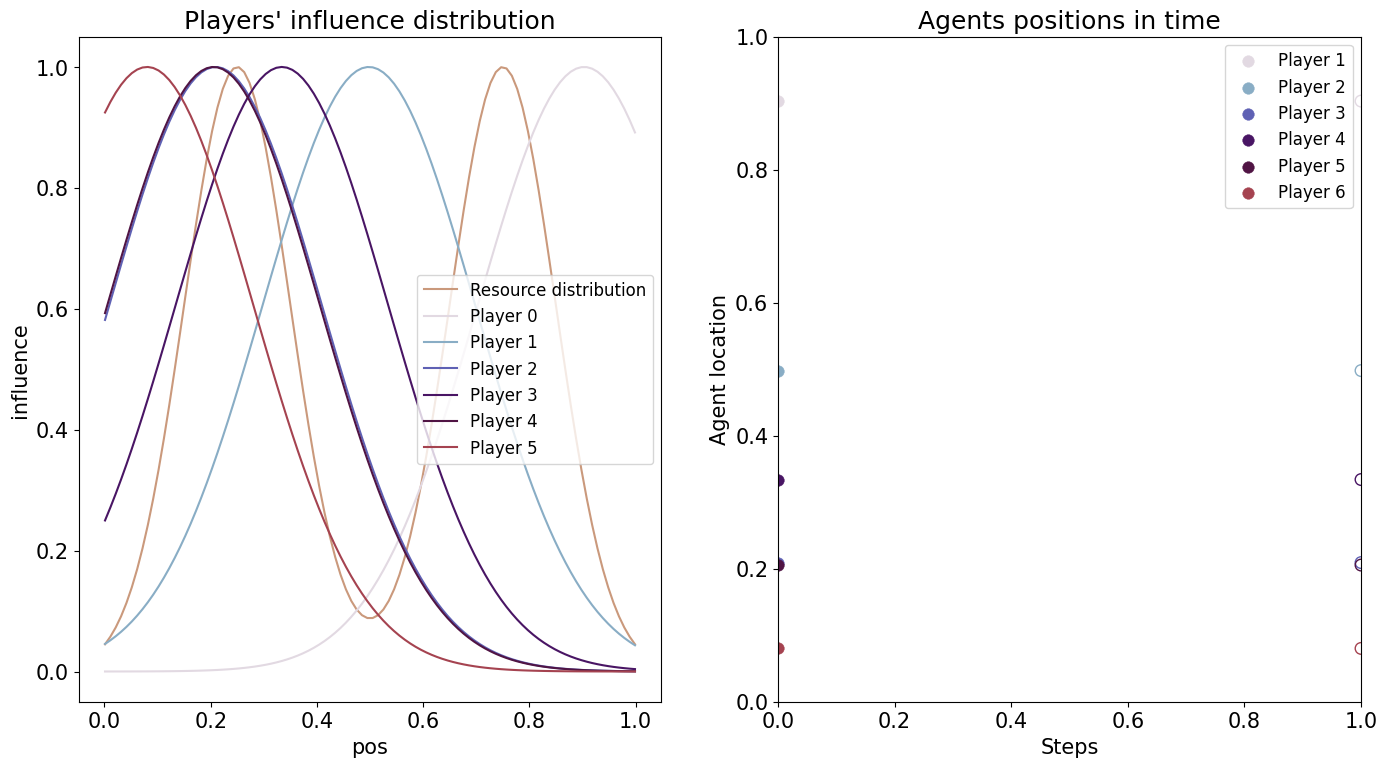

In [39]:
vis.dist_pos_gif(max_frames=1)

In [40]:
import hickle as hkl
def _bif_matrix_data(name='6_bif_sig_x_pos_x.hkl',matrix=None,load=False,save=False):
    if load:
        matrix=hkl.load(name)
        if type(matrix)==dict:
            matrix['max']=torch.tensor(matrix['max'])
            matrix['min']=torch.tensor(matrix['min'])
        else:
            matrix=torch.tensor(matrix)
    elif save:
        if matrix==None:
            raise TypeError('matrix to save cannot be None')
        if type(matrix)== dict:
            if torch.is_tensor(matrix['max']):
                matrix['max']=matrix['max'].numpy()
                matrix['min']=matrix['min'].numpy()
        else:
            matrix=matrix.numpy()
        hkl.dump(matrix,name)
    else:
        raise ValueError('Either load or save must be True')
    return matrix

In [51]:
matrix=_bif_matrix_data(name='6_bif_pos_3.hkl',load=True)

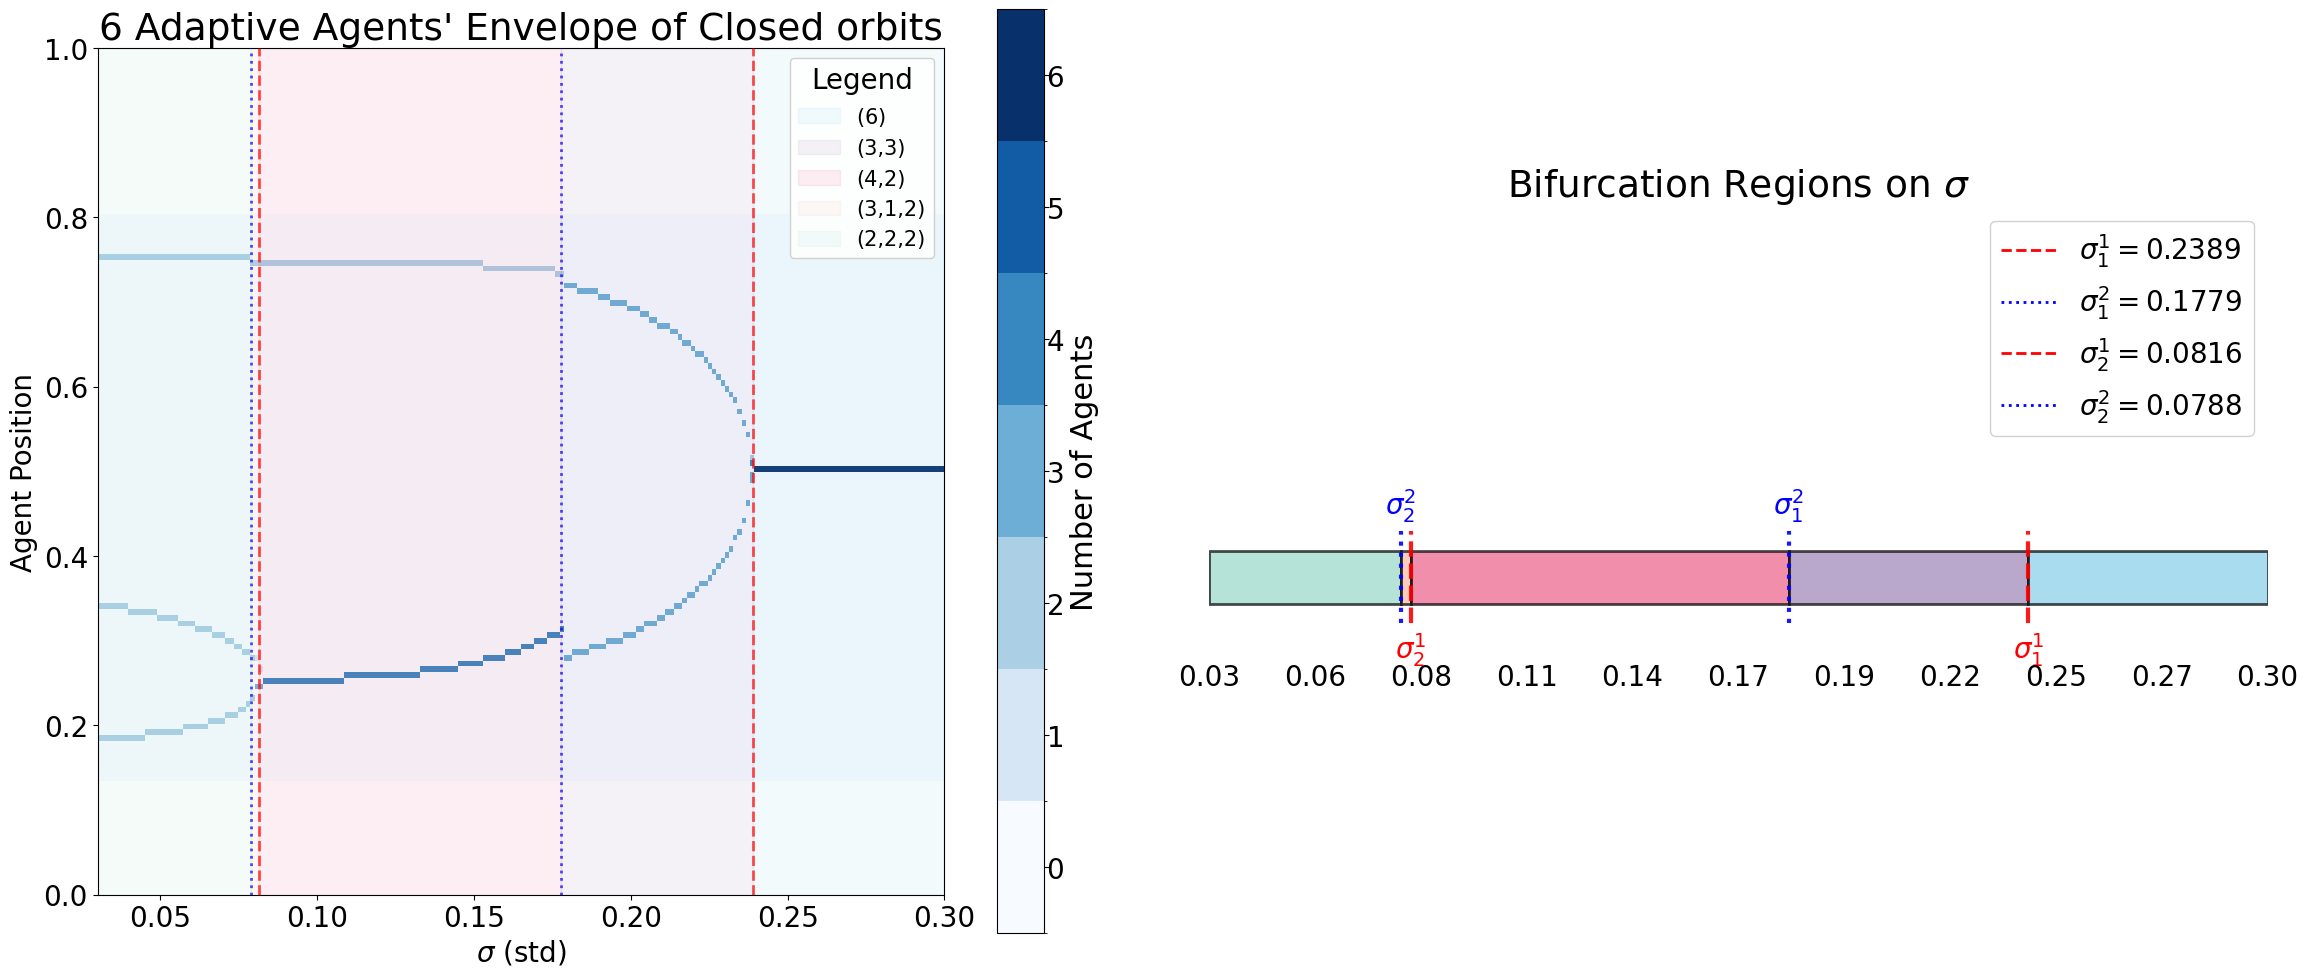

In [43]:
fig,matrix=vis.equilibrium_bifurcation_plot(matrix=None,
                                        reach_start=.03,
                                        reach_end=.3,
                                        reach_num_points=200,
                                        time_steps=10000,
                                        plot_type="heat",
                                        name_ads=[],
                                        title_ads=[],
                                        refinements=10,
                                        parallel_configs={'parallel':True, 'max_workers':8, 'batch_size':4},
                                        font={'default_size': 20,'rect_label_size': 20, 'rect_sigma_size': 20, 'cbar_size': 22, 'title_size': 27, 'legend_size': 15, 'font_family': 'sans-serif'},
                                        cbar_config={'center_labels': True, 'label_alignment': 'center', 'shrink': 0.75},
                                        save=False,
                                        paper_figure={'paper': True, 'section': '3_2','figure_id':'fig1'},
                                        show_pred=False,
                                        optional_vline=None,
                                        envelope=True,
                                        complete=False,
                                        return_matrix=True,
                                        percentage=.5
                                        )
vis.field.pos_matrix=og_pos_matrix
vis.field.grad_matrix=og_grad_matrix
fig

In [45]:
#_bif_matrix_data(name='6_bif_pos_2.hkl',matrix=matrix,save=True)

In [15]:
import InflGame.domains.one_d.one_utils as ou
reach_parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=vis.infl_type,setup_type="parameter_space",reach_start = .03,reach_end = .3,reach_num_points = len(matrix['max']))

bifurcation_types = ou.bifurcation_type_helper(matrix=matrix,reach_parameters=reach_parameters)

In [49]:
import test

In [16]:
bifurcation_types

{'167': {'reach_parameter': 0.2565829145728643,
  'type': '1',
  'classification_new': '(3,3)'},
 '115': {'reach_parameter': 0.18603015075376886,
  'type': '2',
  'classification_new': '(4,2)'},
 '93': {'reach_parameter': 0.15618090452261307,
  'type': '2',
  'classification_new': '(5,1)'},
 '21': {'reach_parameter': 0.05849246231155779,
  'type': '1',
  'classification_new': '(3,2,1)'},
 '2': {'reach_parameter': 0.032713567839195976,
  'type': '1',
  'classification_new': '(2,1,2,1)'}}

In [17]:
reach_parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=vis.infl_type,setup_type="parameter_space",reach_start = .03,reach_end = .3,reach_num_points = len(matrix['max']))
reach_start=reach_parameters[0][0]
reach_end=reach_parameters[-1][0]

(0.03, 0.3)

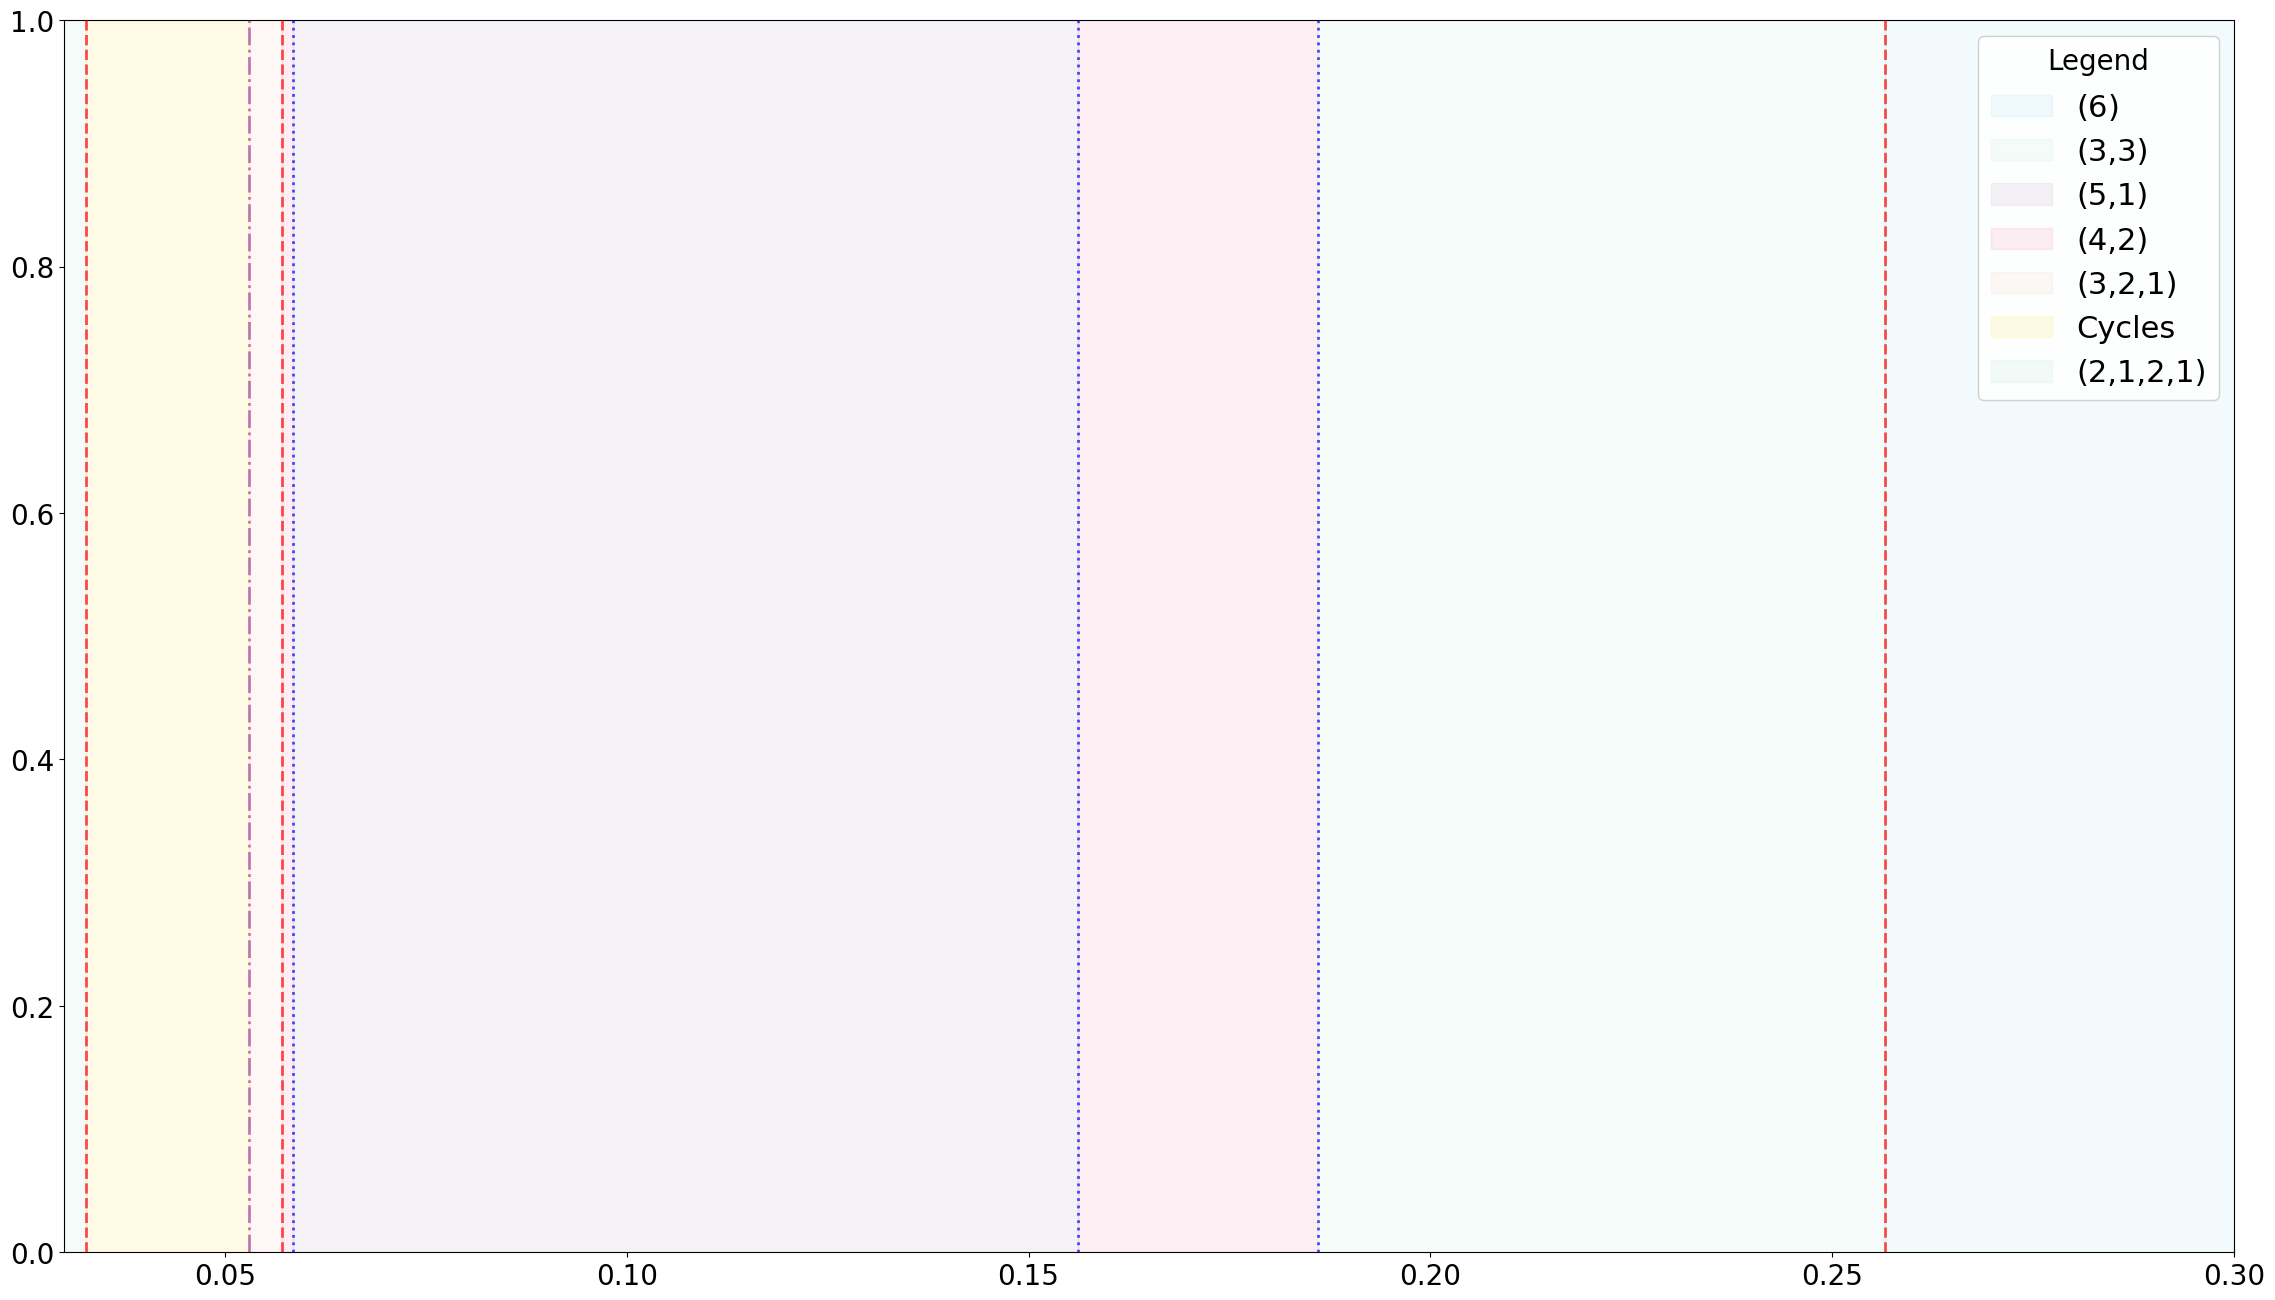

In [58]:
bifurcation_types = ou.bifurcation_type_helper(matrix=matrix,reach_parameters=reach_parameters)
locs = torch.where(torch.round(matrix['min'][:,0], decimals=2) != torch.round(matrix['max'][:,0], decimals=2))
default_font_size=25
legend_font_size=22

fig, ax = plt.subplots(figsize=(28, 16))
# Convert locs to a set of excluded indices
excluded_indices = set(locs[0].tolist())

# Separate bifurcations by type and get classifications, keeping track of which is which
type1_bifurcations = []
type2_bifurcations = []
bifurcation_info = []  # Store all bifurcations with their info

for key, value in bifurcation_types.items():
    # Skip if this key is in the excluded indices
    if int(key) in excluded_indices:
        continue
        
    reach_param = value['reach_parameter']
    bif_type = value['type']
    classification = value['classification_new']
    
    bifurcation_info.append({
        'reach': reach_param,
        'type': bif_type,
        'classification': classification,
        'key': key
    })
    
    if bif_type == '1':
        type1_bifurcations.append(reach_param)
    else:
        type2_bifurcations.append(reach_param)

# Sort bifurcation_info by reach parameter (left to right)
bifurcation_info.sort(key=lambda x: x['reach'])

xlim_start, xlim_end = reach_start, reach_end

# Define color palette for shaded regions
region_colors = plt.cm.Pastel1(np.linspace(0, 1, 9))

# Create shaded regions from right to left
# First, collect all boundaries including xlim_start and xlim_end
boundaries = [xlim_start] + [info['reach'] for info in bifurcation_info] + [xlim_end]

# Get reach parameters for cycle indices
cycle_reach_params = []
if len(excluded_indices) > 0:
    for idx in excluded_indices:
        cycle_reach_params.append(reach_parameters[idx][0].item())

# Shade regions and track legend patches
from matplotlib.patches import Patch

# First pass: collect all unique labels and assign colors
# We need to identify if any regions contain cycles and split them
label_to_color = {}
all_labels = []
final_boundaries = []
final_labels = []

for i in range(len(boundaries) - 1):
    x_start = boundaries[i]
    x_end = boundaries[i + 1]
    
    # Check if any cycle reach values fall within this region
    cycles_in_region = []
    cycle_indices = []
    for idx, cycle_reach in enumerate(cycle_reach_params):
        if x_start < cycle_reach < x_end:
            cycles_in_region.append(cycle_reach)
            cycle_indices.append(idx)
    
    # Get the original region's classification
    if i == len(boundaries) - 2:
        original_label = f'$({num_agents})$'
    elif i < len(bifurcation_info):
        original_label = bifurcation_info[i]['classification']
    else:
        original_label = ''
    
    if cycles_in_region:
        # Sort cycle points to find the range they span
        sorted_pairs = sorted(zip(cycles_in_region, cycle_indices))
        cycles_in_region = [val for val, idx in sorted_pairs]
        cycle_indices = [idx for val, idx in sorted_pairs]
        
        # Get the reach values at index-1 and index+1
        min_idx = cycle_indices[0]
        max_idx = cycle_indices[-1]
        
        cycle_start = x_start  # Use the boundary start instead of calculated cycle_start
        cycle_end = cycle_reach_params[min(len(cycle_reach_params) - 1, max_idx + 2)]
        
        # Create up to 2 sub-regions (no gap before cycles):
        # 1. The cycle region extends from the boundary start
        final_boundaries.append((cycle_start, cycle_end))
        final_labels.append('Cycles')
        
        # 2. After cycles (if there's space)
        if cycle_end < x_end:
            final_boundaries.append((cycle_end, x_end))
            final_labels.append(original_label)
        
    else:
        # No cycles in this region, keep it as is
        final_boundaries.append((x_start, x_end))
        final_labels.append(original_label)

# Assign colors to unique labels with specific colors for certain patterns
import matplotlib.colors as mcolors

# Define specific colors for key patterns
specific_colors = {
    f'$({num_agents})$': '#87CEEB',  # Sky blue for all agents together
    'Cycles': '#FFD700',  # Gold for cycles
    '(2,1,1,2)': '#FF6B6B',  # Coral red for (2,1,1,2)
    '(1,1,1,1,1,1)': '#9370DB'  # Medium purple for (1,1,1,1,1,1)
}

# Additional predefined color palette for other labels
additional_colors = ['#98D8C8', '#F7B7A3', '#EA5F89', '#9D84B7', '#A8E6CF', 
                    '#FFD3B6', '#FFAAA5', '#FF8B94', '#C7CEEA', '#B5EAD7']

# Assign colors to labels
color_index = 0
for label in final_labels:
    if label and label not in label_to_color:
        if label in specific_colors:
            label_to_color[label] = specific_colors[label]
        else:
            # Use predefined color palette
            label_to_color[label] = additional_colors[color_index % len(additional_colors)]
            color_index += 1

# Second pass: draw regions with consistent colors and add to legend
seen_labels = set()
x_pos_list = []

for i, (x_start, x_end) in enumerate(final_boundaries):
    label = final_labels[i]
    color = label_to_color.get(label, region_colors[0])
    
    # Only add label if it's the first occurrence (for legend)
    plot_label = label if (label and label not in seen_labels) else None
    if plot_label:
        seen_labels.add(label)
    
    # Add shaded region with label
    ax.axvspan(x_start, x_end, alpha=0.1, color=color, zorder=0, label=plot_label)

# Plot type 1 bifurcation lines without labels
for i, reach_param in enumerate(type1_bifurcations):
    ax.axvline(x=reach_param, color='red', linestyle='--', linewidth=2, alpha=0.7, zorder=10,
                label=f'$\\sigma_{i+1}^1 = {reach_param:.4f}$')

# Plot type 2 bifurcation lines without labels
for j, reach_param in enumerate(type2_bifurcations):
    ax.axvline(x=reach_param, color='blue', linestyle=':', linewidth=2, alpha=0.7, zorder=10,
                label=f'$\\sigma_{j+1}^2 = {reach_param:.4f}$')

# Plot cycle bifurcation line without label (if cycles exist)
if len(cycle_reach_params) > 0:
    cycle_end_param = max(cycle_reach_params)
    ax.axvline(x=cycle_end_param, color='purple', linestyle='-.', linewidth=2, alpha=0.5, zorder=10,
                label=f'$\\sigma^{{cycle}} = {cycle_end_param:.4f}$')

# Simplified legend: gather all labeled elements automatically
handles, labels = ax.get_legend_handles_labels()

# Separate into categories while preserving original order
region_items = []
bifurcation_items = []
envelope_items = []

for handle, label in zip(handles, labels):
    if 'sigma' in label.lower():
        # Extract bifurcation label and parameter value
        # Label format: '$\sigma_1^1 = 0.1234$'
        bifurcation_items.append((handle, label))
    elif label in ['Upper', 'Lower']:
        envelope_items.append((handle, label))
    else:
        region_items.append((handle, label))

# Reverse region order for right-to-left display (regions appear left to right in plot)
region_items.reverse()

# Extract handles and labels from tuples
region_handles = [h for h, l in region_items]
region_labels = [l for h, l in region_items]
envelope_handles = [h for h, l in envelope_items]
envelope_labels = [l for h, l in envelope_items]

# Combine regions and envelope for legend (no bifurcations)
combined_handles = region_handles + envelope_handles
combined_labels = region_labels + envelope_labels

# Create legend in upper right corner of main plot
ax.legend(handles=combined_handles, labels=combined_labels, 
            loc='upper right', 
            fontsize=legend_font_size, title='Legend', framealpha=0.9)

ax.set_xlim(reach_start,reach_end)


In [54]:
reach_start

tensor(0.0300, dtype=torch.float64)

In [60]:
matrix1=_bif_matrix_data(name='6_bif_pos_1.hkl',load=True)
matrix2=_bif_matrix_data(name='6_bif_pos_2.hkl',load=True)


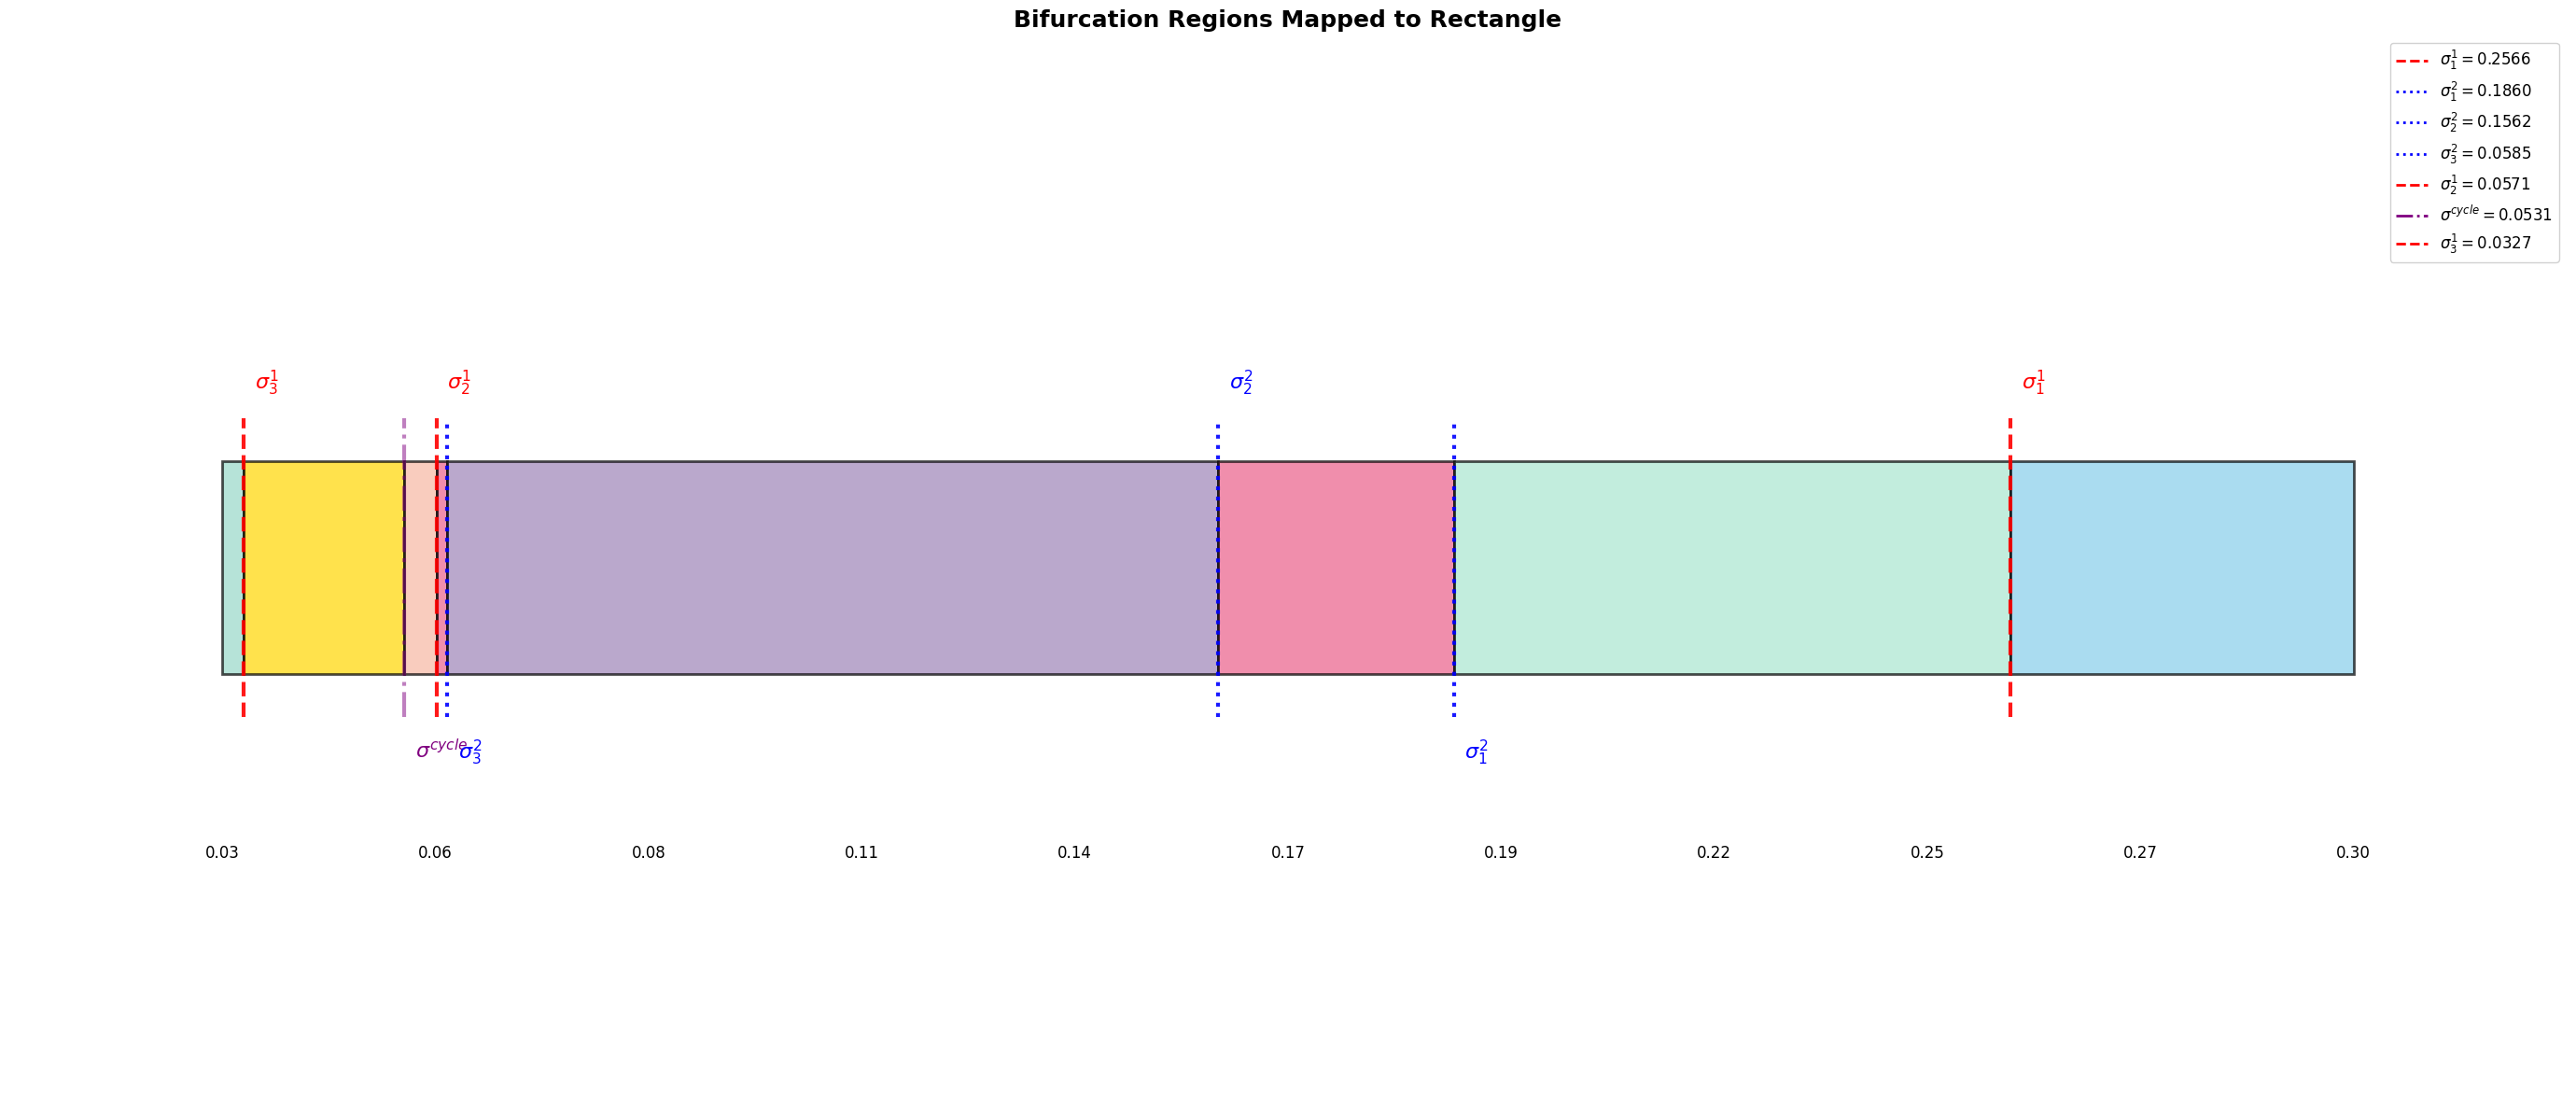

In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Create a figure and an axes object
fig, ax = plt.subplots(figsize=(28, 16))
ax.set_axis_off()
# 2. Define the overall rectangle parameters
rect_height = 1
rect_y_start = 2

# 3. Scale factor to map from sigma space to rectangle width
sigma_min = reach_start.item() if hasattr(reach_start, 'item') else reach_start
sigma_max = reach_end.item() if hasattr(reach_end, 'item') else reach_end
rect_x_start = 1  # Start position of rectangle
rect_total_width = 10  # Total width of rectangle

# Function to convert sigma value to x-coordinate in rectangle
def sigma_to_x(sigma):
    return rect_x_start + (sigma - sigma_min) / (sigma_max - sigma_min) * rect_total_width

# 4. Draw each segment with corresponding color from bifurcation plot
for i, (x_start_sigma, x_end_sigma) in enumerate(final_boundaries):
    # Convert sigma boundaries to rectangle coordinates
    segment_x_start = sigma_to_x(x_start_sigma)
    segment_x_end = sigma_to_x(x_end_sigma)
    segment_width = segment_x_end - segment_x_start
    
    # Get the color for this segment
    label = final_labels[i]
    color = label_to_color.get(label, '#CCCCCC')  # Default gray if no color assigned
    
    # Create the rectangle segment
    rectangle = patches.Rectangle(
        (segment_x_start, rect_y_start),
        segment_width,
        rect_height,
        facecolor=color,
        edgecolor='black',
        linewidth=2,
        alpha=0.7
    )
    
    # Add the patch to the Axes
    ax.add_patch(rectangle)

# 5. Draw vertical lines at bifurcation points matching the previous plot
x_pos_list = []
label_counter = 0  # Counter to alternate label positions

# Combine all bifurcations with their types for processing
all_bifurcations = []
for i, reach_param in enumerate(type1_bifurcations):
    if sigma_min <= reach_param <= sigma_max:
        all_bifurcations.append(('type1', i, reach_param))

for j, reach_param in enumerate(type2_bifurcations):
    if sigma_min <= reach_param <= sigma_max:
        all_bifurcations.append(('type2', j, reach_param))

if len(cycle_reach_params) > 0:
    cycle_end_param = max(cycle_reach_params)
    if sigma_min <= cycle_end_param <= sigma_max:
        all_bifurcations.append(('cycle', 0, cycle_end_param))

# Sort by position
all_bifurcations.sort(key=lambda x: x[2])

# Draw all bifurcations with alternating labels
for bif_type, idx, reach_param in all_bifurcations:
    x_pos = sigma_to_x(reach_param)
    
    if bif_type == 'type1':
        color = 'red'
        linestyle = '--'
        alpha = 0.9
        label_text = f'$\\sigma_{idx+1}^1$'
    elif bif_type == 'type2':
        color = 'blue'
        linestyle = ':'
        alpha = 0.9
        label_text = f'$\\sigma_{idx+1}^2$'
    else:  # cycle
        color = 'purple'
        linestyle = '-.'
        alpha = 0.5
        label_text = '$\\sigma^{cycle}$'
    
    # Draw vertical line
    ax.axvline(x=x_pos, ymin=(rect_y_start-0.2)/5, ymax=(rect_y_start+rect_height+0.2)/5,
               color=color, linestyle=linestyle, linewidth=3, alpha=alpha, zorder=10)
    
    # Alternate label position: above or below
    if label_counter % 2 == 0:
        # Above the rectangle
        label_y_pos = rect_y_start + rect_height + 0.3
        va = 'bottom'
    else:
        # Below the rectangle
        label_y_pos = rect_y_start - 0.3
        va = 'top'
    
    label_x_pos = x_pos + 0.05
    
    ax.text(label_x_pos, label_y_pos, label_text,
            fontsize=16, color=color, fontweight='bold',
            ha='left', va=va)
    
    label_counter += 1

# 6. Set axis limits and labels for proper visualization
ax.set_xlim(0, rect_x_start + rect_total_width + 1)
ax.set_ylim(0, 5)
ax.set_xlabel('Sigma ($\\sigma$) - Agent Reach Parameter', fontsize=16)
ax.set_ylabel('', fontsize=16)
ax.set_title('Bifurcation Regions Mapped to Rectangle', fontsize=18, fontweight='bold')

# Add sigma value labels below the rectangle
sigma_step = (sigma_max - sigma_min) / 10
sigma_labels_vals = [sigma_min + i * sigma_step for i in range(11)]
for sigma_val in sigma_labels_vals:
    x_pos = sigma_to_x(sigma_val)
    ax.text(x_pos, rect_y_start - 0.8, f'{sigma_val:.2f}',
            ha='center', va='top', fontsize=12, color='black')

# Create legend with bifurcation lines and their values
from matplotlib.lines import Line2D
legend_data = []

# Collect type 1 bifurcations
for i, reach_param in enumerate(type1_bifurcations):
    if sigma_min <= reach_param <= sigma_max:
        legend_data.append((reach_param, 'red', '--', f'$\\sigma_{i+1}^1 = {reach_param:.4f}$'))

# Collect type 2 bifurcations
for j, reach_param in enumerate(type2_bifurcations):
    if sigma_min <= reach_param <= sigma_max:
        legend_data.append((reach_param, 'blue', ':', f'$\\sigma_{j+1}^2 = {reach_param:.4f}$'))

# Collect cycle bifurcation if it exists
if len(cycle_reach_params) > 0:
    cycle_end_param = max(cycle_reach_params)
    if sigma_min <= cycle_end_param <= sigma_max:
        legend_data.append((cycle_end_param, 'purple', '-.', f'$\\sigma^{{cycle}} = {cycle_end_param:.4f}$'))

# Sort by sigma value in descending order (first element in tuple)
legend_data.sort(key=lambda x: x[0], reverse=True)

# Create legend elements in sorted order
legend_elements = []
for reach_param, color, linestyle, label in legend_data:
    legend_elements.append(Line2D([0], [0], color=color, linestyle=linestyle, linewidth=2, label=label))

# Add legend to the plot
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, framealpha=0.9)

# 7. Display the plot
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [ ]:
matrix['max'][153]

tensor([0.5401, 0.5401, 0.5400, 0.4600, 0.4599, 0.4599])

In [ ]:
def reward_bifurcation_matrix_setup(field, matrix,reach_parameters):
    reward_bifurcation_matrix={'max':[], 'min':[], 'reach_parameters':[],'same':[]}
    # check if the max and the min are equal
    for i in range(len(matrix['max'])):
        if torch.all(matrix['max'][i]==matrix['min'][i]):
            vis.field.agents_pos=matrix['max'][i]
            reward_bifurcation_matrix['max'].append(field.reward_F(parameter_instance=vis.parameters))
            reward_bifurcation_matrix['min'].append(field.reward_F(parameter_instance=vis.parameters))
            reward_bifurcation_matrix['same'].append(1)
            reward_bifurcation_matrix['reach_parameters'].append(reach_parameters[i][0])
        else:
            vis.field.agents_pos=matrix['max'][i]
            reward_bifurcation_matrix['max'].append(field.reward_F(parameter_instance=vis.parameters))
            vis.field.agents_pos=matrix['min'][i]
            reward_bifurcation_matrix['min'].append(field.reward_F(parameter_instance=vis.parameters))
            reward_bifurcation_matrix['same'].append(0)
            reward_bifurcation_matrix['reach_parameters'].append(reach_parameters[i][0])
    reward_bifurcation_matrix['max']=torch.stack(reward_bifurcation_matrix['max'],dim=0)
    reward_bifurcation_matrix['min']=torch.stack(reward_bifurcation_matrix['min'],dim=0)
    reward_bifurcation_matrix['reach_parameters']=torch.stack(reward_bifurcation_matrix['reach_parameters'])
    return reward_bifurcation_matrix

In [ ]:
reward_bifurcation_matrix=reward_bifurcation_matrix_setup(vis.field, matrix,reach_parameters=reach_parameters)


In [ ]:
reward_bifurcation_matrix

{'max': tensor([[ 7.9531,  7.9531,  8.8220,  8.8220,  7.9531,  7.9531],
         [ 7.9624,  7.9624,  8.8033,  8.8033,  7.9624,  7.9624],
         [ 6.5515,  6.5518,  7.1980,  9.2891,  9.5538, 10.3120],
         ...,
         [ 8.2427,  8.2427,  8.2427,  8.2427,  8.2427,  8.2427],
         [ 8.2427,  8.2427,  8.2427,  8.2427,  8.2427,  8.2427],
         [ 8.2427,  8.2427,  8.2427,  8.2427,  8.2427,  8.2427]]),
 'min': tensor([[ 7.9531,  7.9531,  8.8220,  8.8220,  7.9531,  7.9531],
         [ 7.9624,  7.9624,  8.8033,  8.8033,  7.9624,  7.9624],
         [10.3132,  9.5555,  9.2905,  7.1970,  6.5543,  6.5457],
         ...,
         [ 8.2427,  8.2427,  8.2427,  8.2427,  8.2427,  8.2427],
         [ 8.2427,  8.2427,  8.2427,  8.2427,  8.2427,  8.2427],
         [ 8.2427,  8.2427,  8.2427,  8.2427,  8.2427,  8.2427]]),
 'reach_parameters': tensor([0.0300, 0.0314, 0.0327, 0.0341, 0.0354, 0.0368, 0.0381, 0.0395, 0.0409,
         0.0422, 0.0436, 0.0449, 0.0463, 0.0476, 0.0490, 0.0504, 0.0517, 

In [ ]:
idx = 1
def rewards_stacked_rectangle_plot(idx, matrix, reward_bifurcation_matrix, max_reward=None):
    fig, ax = plt.subplots(figsize=(24, 12))
    ax.set_box_aspect(1)
    reach_parameter=reward_bifurcation_matrix['reach_parameters'][idx].item()
    if reward_bifurcation_matrix['same'][idx] == 1:
        # No bifurcation case - use max positions
        positions_array = torch.round(matrix['max'][idx], decimals=2).numpy()
        rewards_array = reward_bifurcation_matrix['max'][idx].numpy()
        
        # Group agents by position
        from collections import defaultdict
        position_groups = defaultdict(list)
        for agent_idx, (pos, reward) in enumerate(zip(positions_array, rewards_array)):
            position_groups[pos].append(reward)
        
        # Draw stacked rectangles for each position
        colors = plt.cm.Set3(np.linspace(0, 1, 12))  # Color palette for different agents
        box_width = 0.035
        total_reward_list=[]    
        for pos_idx, (pos, rewards) in enumerate(sorted(position_groups.items())):
            n_agents = len(rewards)
            total_reward = sum(rewards)
            total_reward_list.append(total_reward)
            segment_height = total_reward / n_agents
            
            # Draw each agent's segment
            for i, reward in enumerate(rewards):
                bottom = i * segment_height
                height = segment_height
                
                # Create rectangle
                rect = plt.Rectangle((pos - box_width/2, bottom), box_width, height,
                                    facecolor=colors[i % len(colors)],
                                    edgecolor='black',
                                    linewidth=1.5,
                                    alpha=0.8)
                ax.add_patch(rect)
                
                
            
            # Add position label at top
            ax.text(pos, total_reward+1, f'n={n_agents}',
                ha='center', va='top', fontsize=10, color='darkblue', fontweight='bold')
            
            # Draw outline box around all segments
            rect_outline = plt.Rectangle((pos - box_width/2, 0), box_width, total_reward,
                                        facecolor='none',
                                        edgecolor='darkblue',
                                        linewidth=2.5)
            ax.add_patch(rect_outline)
        
        # Add parameter box in upper right corner
        from matplotlib.patches import FancyBboxPatch
        calculated_max_reward = max(total_reward_list)
        textstr = f'$\\sigma = {reach_parameter:.3f}$'
        props = dict(boxstyle='round,pad=0.5', facecolor='wheat', edgecolor='black', linewidth=2, alpha=0.9)
        # Use provided max_reward if available, otherwise use calculated
        text_y_pos = (max_reward if max_reward is not None else calculated_max_reward) * .95
        ax.text(0.98, text_y_pos, textstr, transform=ax.transData,
                fontsize=20, verticalalignment='top', horizontalalignment='right',
                bbox=props)
        
        ax.set_title(f'Stacked Reward Distribution by Position (Parameter Point {idx}, No Bifurcation)', fontsize=16)
        ax.set_xlabel('Agent Position', fontsize=14)
        ax.set_ylabel('Total Reward (Stacked)', fontsize=14)
        ax.set_xlim(-0.05, 1.05)
        if max_reward is not None:
            ax.set_ylim(0, max_reward)
        else:
            ax.set_ylim(0, calculated_max_reward*1.2)
        ax.grid(True, alpha=0.3, axis='y')
        
    else:
        # Bifurcation case - show both max and min equilibria
        positions_max = torch.round(matrix['max'][idx], decimals=2).numpy()
        rewards_max = reward_bifurcation_matrix['max'][idx].numpy()
        positions_min = torch.round(matrix['min'][idx], decimals=2).numpy()
        rewards_min = reward_bifurcation_matrix['min'][idx].numpy()
        
        # Group agents by position for both equilibria
        from collections import defaultdict
        position_groups_max = defaultdict(list)
        for pos, reward in zip(positions_max, rewards_max):
            position_groups_max[pos].append(reward)
        
        position_groups_min = defaultdict(list)
        for pos, reward in zip(positions_min, rewards_min):
            position_groups_min[pos].append(reward)
        
        # Draw stacked rectangles
        colors = plt.cm.Set3(np.linspace(0, 1, 12))
        box_width = 0.012
        offset = box_width * 0.6
        total_reward_list=[]
        # Max equilibrium (left side)
        for pos, rewards in sorted(position_groups_max.items()):
            n_agents = len(rewards)
            total_reward = sum(rewards)
            total_reward_list.append(total_reward)
            segment_height = total_reward / n_agents
            
            for i, reward in enumerate(rewards):
                bottom = i * segment_height
                height = segment_height
                
                rect = plt.Rectangle((pos - offset - box_width/2, bottom), box_width, height,
                                    facecolor=colors[i % len(colors)],
                                    edgecolor='blue',
                                    linewidth=1.2,
                                    alpha=0.7)
                ax.add_patch(rect)
                
                ax.text(pos - offset, bottom + height/2, f'{reward:.3f}',
                    ha='center', va='center', fontsize=7, color='darkblue')
            
            # Outline
            rect_outline = plt.Rectangle((pos - offset - box_width/2, 0), box_width, total_reward,
                                        facecolor='none',
                                        edgecolor='blue',
                                        linewidth=2)
            ax.add_patch(rect_outline)
            
            ax.text(pos - offset, -0.01, f'n={n_agents}',
                ha='center', va='top', fontsize=9, color='blue', fontweight='bold')
        
        # Min equilibrium (right side)
        
        for pos, rewards in sorted(position_groups_min.items()):
            n_agents = len(rewards)
            total_reward = sum(rewards)
            segment_height = total_reward / n_agents
            total_reward_list.append(total_reward)
            for i, reward in enumerate(rewards):
                bottom = i * segment_height
                height = segment_height
                
                rect = plt.Rectangle((pos + offset - box_width/2, bottom), box_width, height,
                                    facecolor=colors[i % len(colors)],
                                    edgecolor='red',
                                    linewidth=1.2,
                                    alpha=0.7)
                ax.add_patch(rect)
                
                ax.text(pos + offset, bottom + height/2, f'{reward:.3f}',
                    ha='center', va='center', fontsize=7, color='darkred')
            
            # Outline
            rect_outline = plt.Rectangle((pos + offset - box_width/2, 0), box_width, total_reward,
                                        facecolor='none',
                                        edgecolor='red',
                                        linewidth=2)
            ax.add_patch(rect_outline)
            
            ax.text(pos + offset, -0.01, f'n={n_agents}',
                ha='center', va='top', fontsize=9, color='red', fontweight='bold')
        
        # Add parameter box in upper right corner
        from matplotlib.patches import FancyBboxPatch
        calculated_max_reward = max(total_reward_list)
        textstr = f'$\\sigma = {reach_parameter:.3f}$'
        props = dict(boxstyle='round,pad=0.5', facecolor='wheat', edgecolor='black', linewidth=2, alpha=0.9)
        # Use provided max_reward if available, otherwise use calculated
        text_y_pos = (max_reward if max_reward is not None else calculated_max_reward) *.95
        ax.text(0.98, text_y_pos, textstr, transform=ax.transData,
                fontsize=20, verticalalignment='top', horizontalalignment='right',
                bbox=props)
        
        # Create custom legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='white', edgecolor='blue', linewidth=2, label='Max Equilibrium'),
                        Patch(facecolor='white', edgecolor='red', linewidth=2, label='Min Equilibrium')]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=12)
        
        ax.set_title(f'Stacked Reward Distribution by Position (Parameter Point {idx}, Bifurcation)', fontsize=16)
        ax.set_xlabel('Agent Position', fontsize=14)
        ax.set_ylabel('Total Reward (Stacked)', fontsize=14)
        ax.set_xlim(-0.05, 1.05)
        if max_reward is not None:
            ax.set_ylim(0, max_reward)
        else:
            ax.set_ylim(0, calculated_max_reward*1.2)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

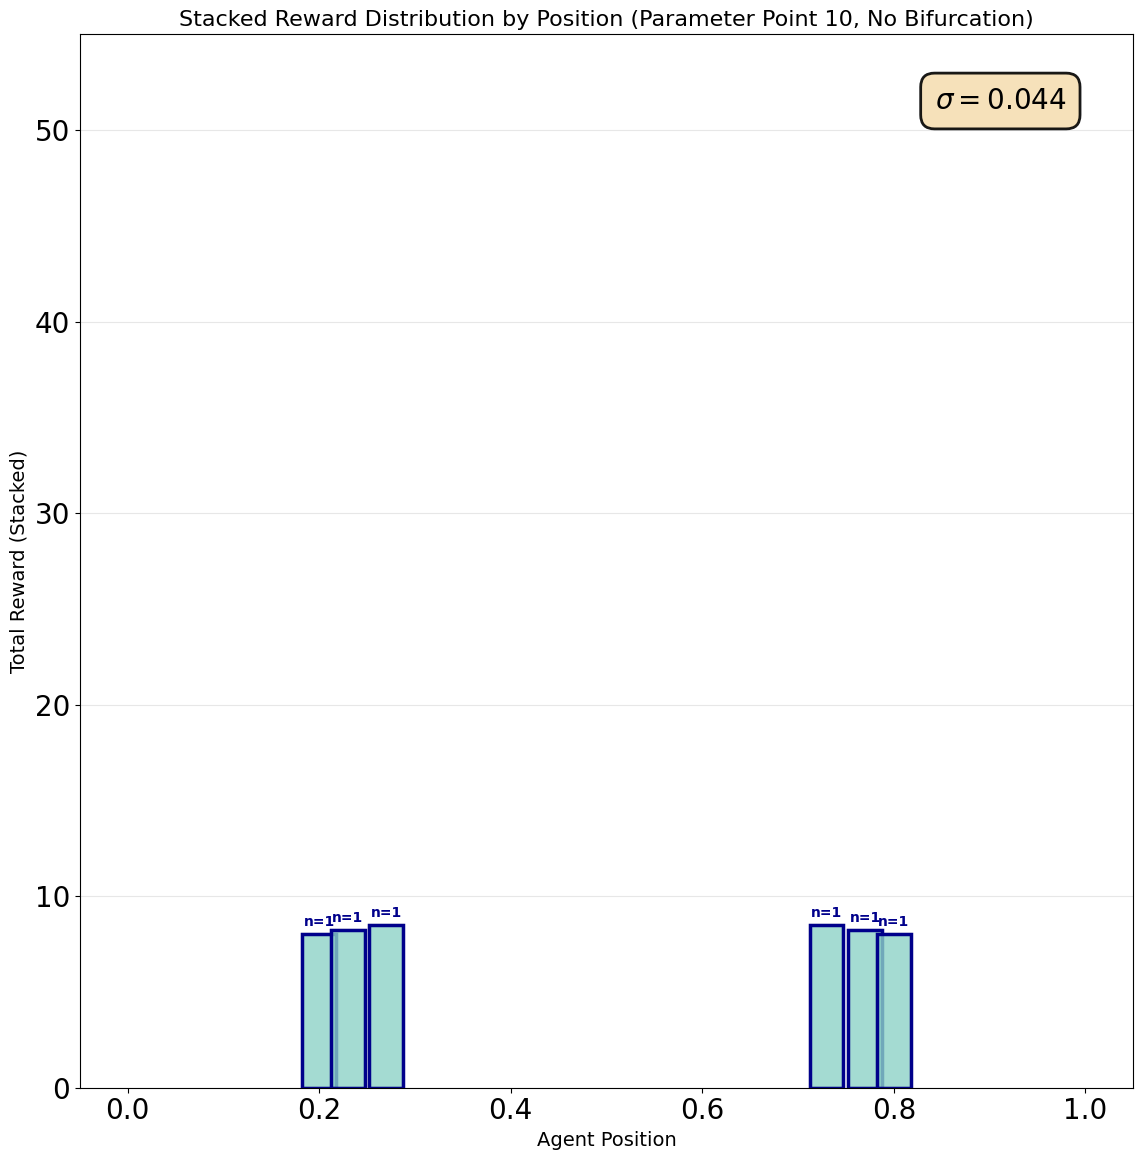

In [ ]:
rewards_stacked_rectangle_plot(10, matrix, reward_bifurcation_matrix,max_reward = 55)

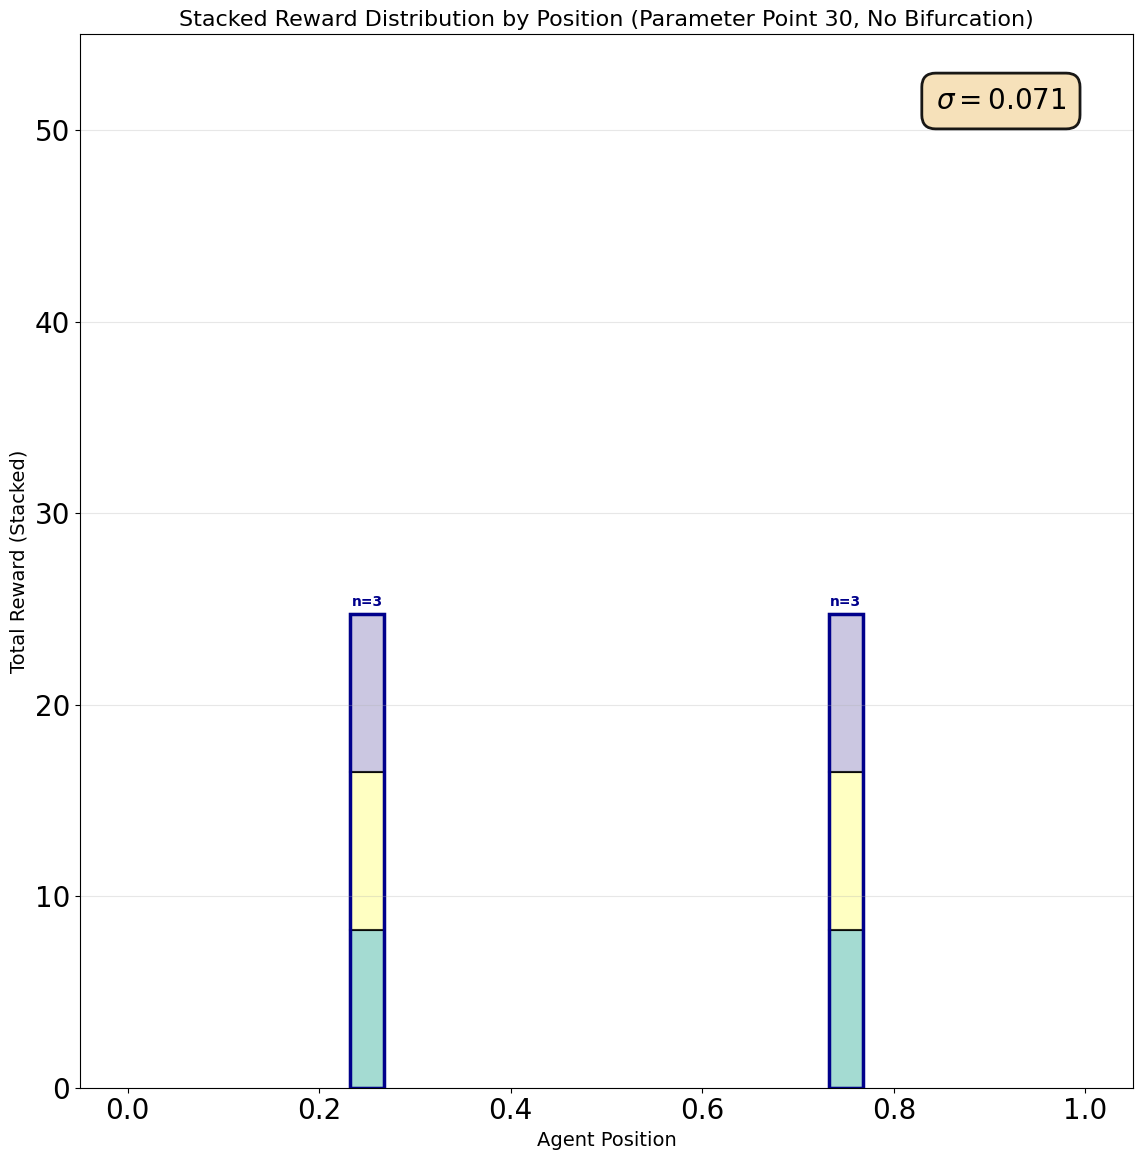

In [ ]:
rewards_stacked_rectangle_plot(30, matrix, reward_bifurcation_matrix,max_reward=55)

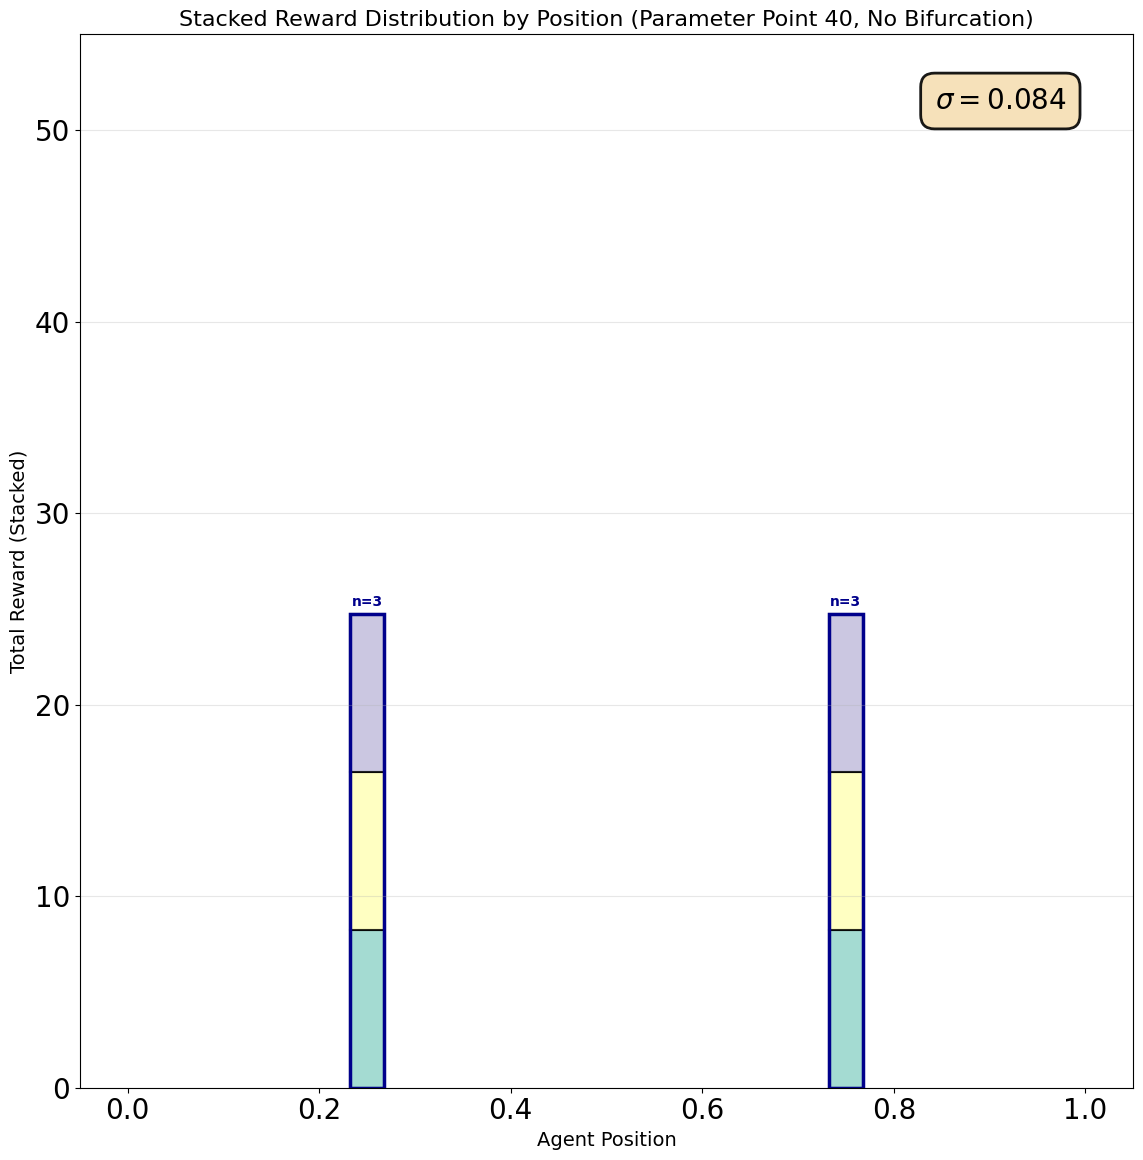

In [ ]:
rewards_stacked_rectangle_plot(40, matrix, reward_bifurcation_matrix,max_reward=55)

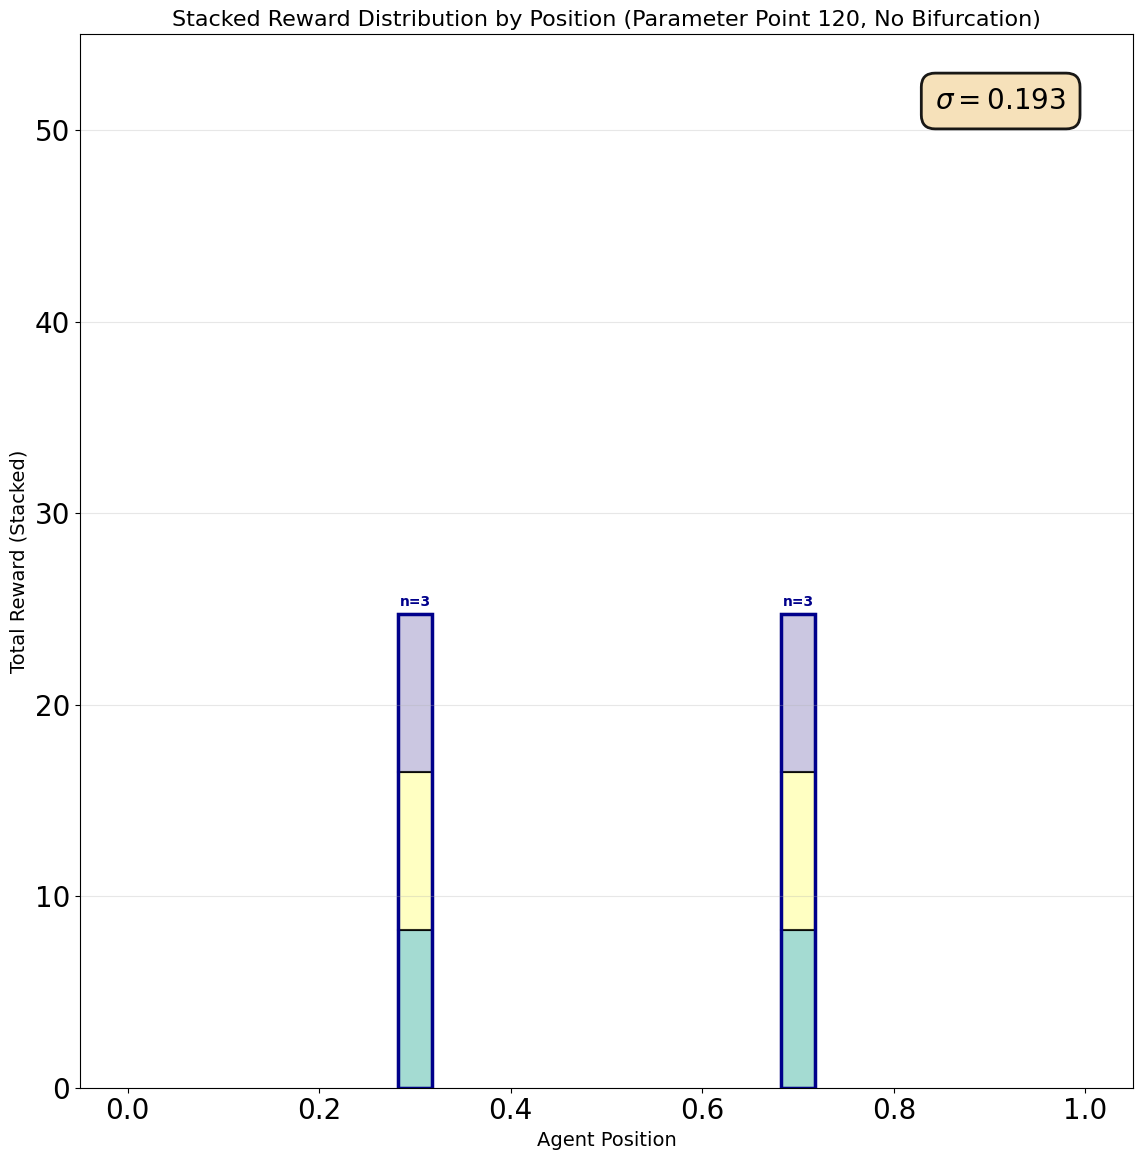

In [ ]:
rewards_stacked_rectangle_plot(120, matrix, reward_bifurcation_matrix,max_reward=55)

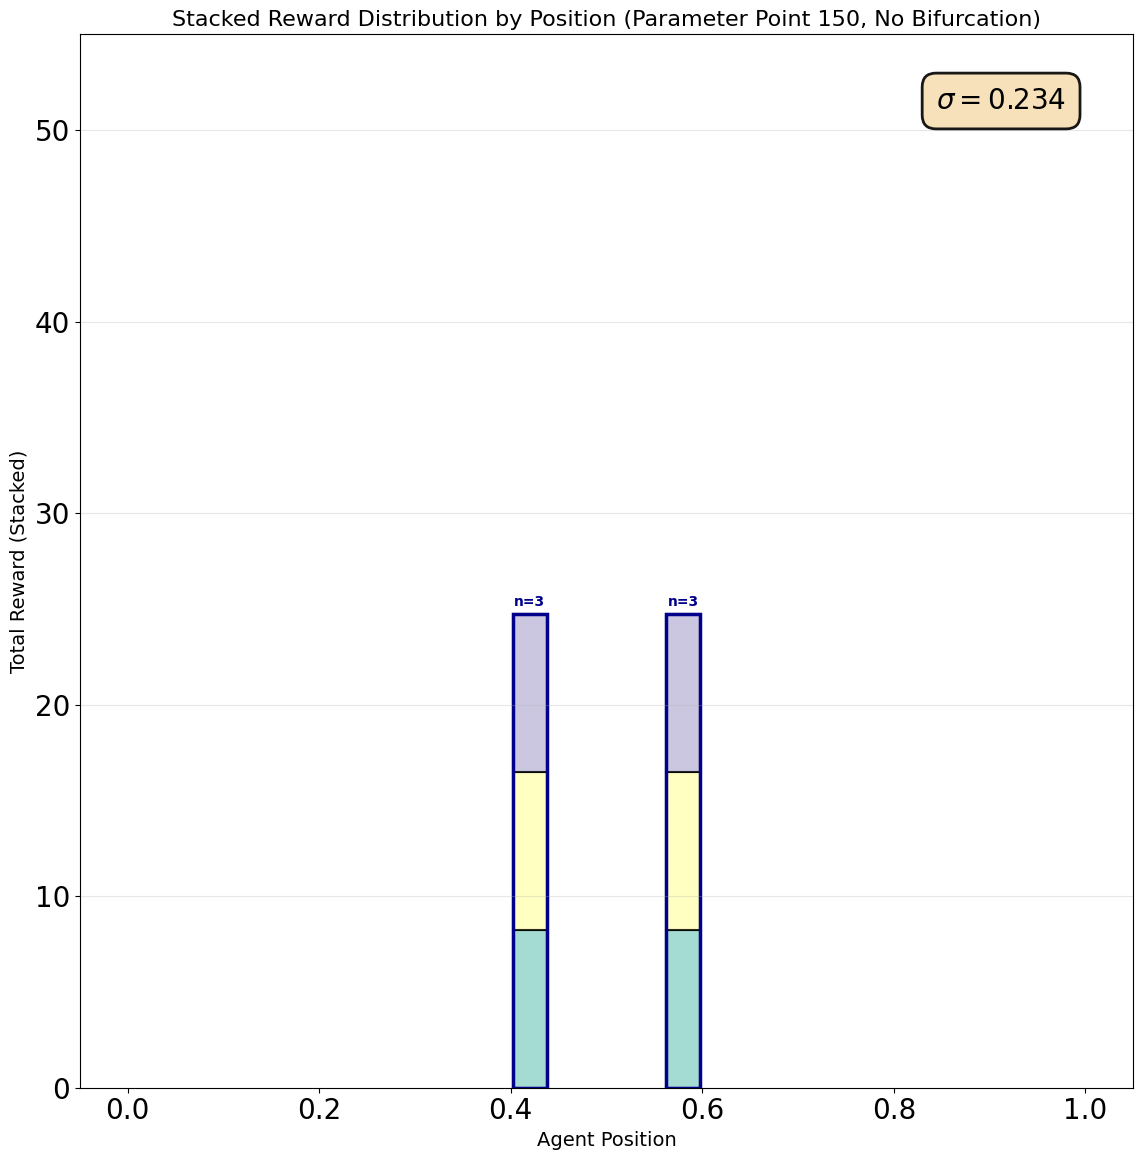

In [ ]:
rewards_stacked_rectangle_plot(150, matrix, reward_bifurcation_matrix,max_reward=55)

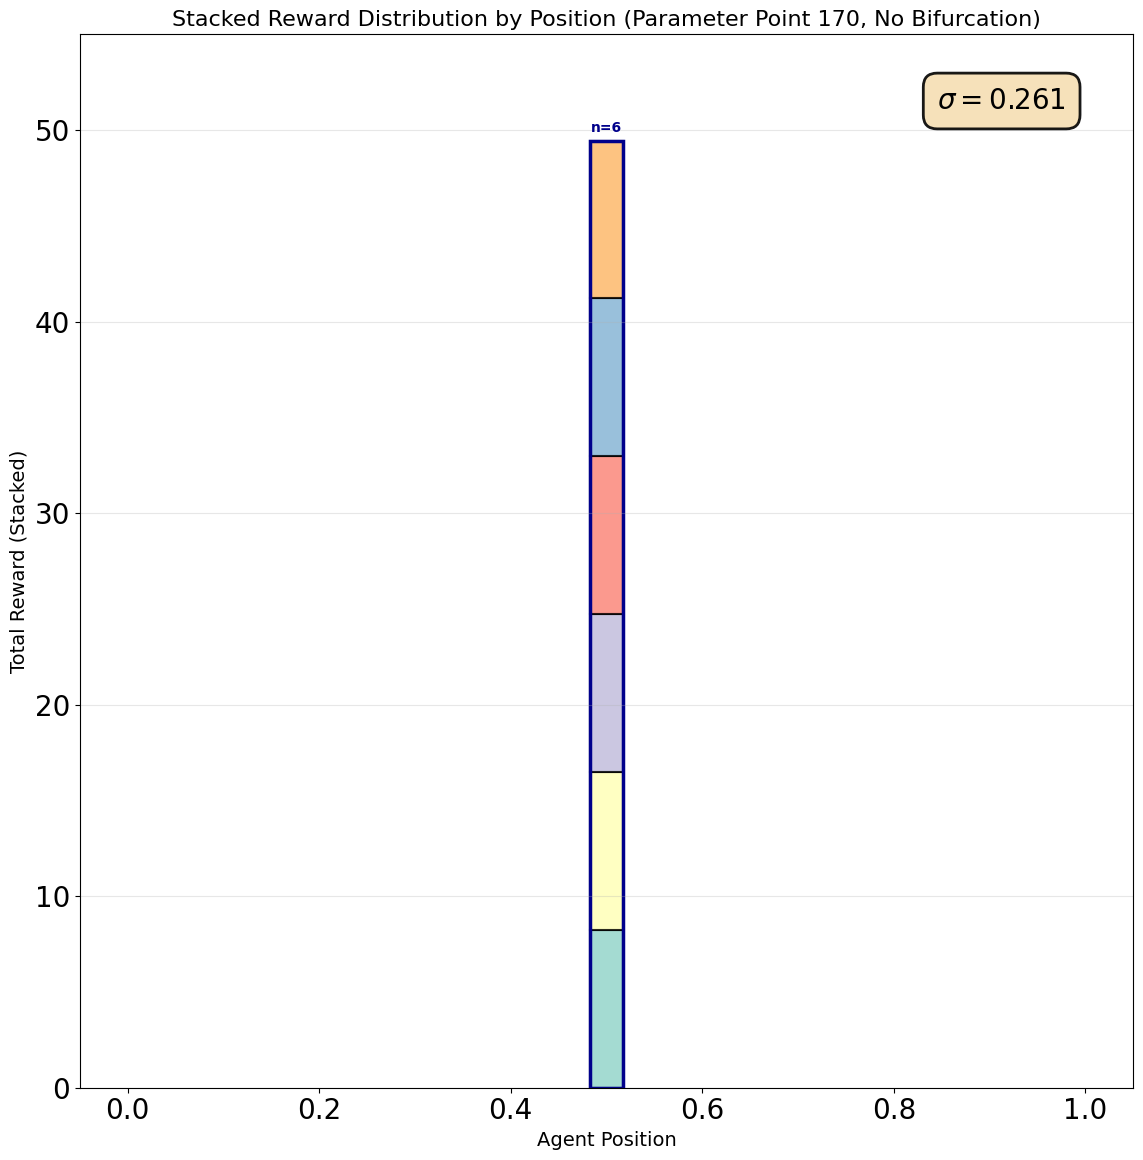

In [ ]:
rewards_stacked_rectangle_plot(170, matrix, reward_bifurcation_matrix,max_reward=55)

In [84]:
def bifurcation_tree_plot(main_matrix, left_matrices, right_matrices, 
                          reach_parameters, num_agents, 
                          reach_start, reach_end, 
                          label_to_color=None, 
                          figsize=(20, 24),
                          rect_width=0.8,
                          horizontal_spacing=2.5,
                          box_height=10,
                          font_size=14,
                          show_labels=False):
    """
    Create a vertical tree plot with a main rectangle and left/right branches based on bifurcation changes.
    
    Parameters:
    -----------
    main_matrix : dict
        Main bifurcation matrix containing 'max', 'min', etc.
    left_matrices : list of dict
        List of matrices for left branches
    right_matrices : list of dict
        List of matrices for right branches
    reach_parameters : list of torch.Tensor
        Reach parameters for each matrix
    num_agents : int
        Number of agents in the system
    reach_start : float
        Starting sigma value
    reach_end : float
        Ending sigma value
    label_to_color : dict, optional
        Mapping of classification labels to colors
    figsize : tuple
        Figure size (width, height)
    rect_width : float
        Width of each rectangle
    horizontal_spacing : float
        Spacing between rectangles
    box_height : float
        Total height of each rectangle
    font_size : int
        Font size for labels
    show_labels : bool
        Whether to show classification labels on rectangles
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import InflGame.domains.one_d.one_utils as ou
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    
    # Starting y position for rectangles
    rect_y_start = 1
    
    # Helper function to process a matrix and extract segment info
    def process_matrix(matrix):
        # Get bifurcation types for this matrix
        bifurcation_types = ou.bifurcation_type_helper(
            matrix=matrix, 
            reach_parameters=reach_parameters
        )
        
        # Find cycle locations
        locs = torch.where(
            torch.round(matrix['min'][:,0], decimals=2) != 
            torch.round(matrix['max'][:,0], decimals=2)
        )
        excluded_indices = set(locs[0].tolist())
        
        # Get cycle reach parameters if they exist
        cycle_reach_params = []
        if len(excluded_indices) > 0:
            for idx in excluded_indices:
                cycle_reach_params.append(reach_parameters[idx][0].item())
        
        # Collect bifurcation info
        bifurcation_info = []
        for key, value in bifurcation_types.items():
            if int(key) in excluded_indices:
                continue
            
            bifurcation_info.append({
                'reach': value['reach_parameter'],
                'type': value['type'],
                'classification': value['classification_new'],
                'key': key
            })
        
        # Sort by reach parameter
        bifurcation_info.sort(key=lambda x: x['reach'])
        
        # Create boundaries
        boundaries = [reach_start] + \
                     [info['reach'] for info in bifurcation_info] + \
                     [reach_end]
        
        # Build final segments with labels
        final_boundaries = []
        final_labels = []
        
        for i in range(len(boundaries) - 1):
            x_start = boundaries[i]
            x_end = boundaries[i + 1]
            
            # Check for cycles in this region
            cycles_in_region = []
            cycle_indices = []
            for idx, cycle_reach in enumerate(cycle_reach_params):
                if x_start < cycle_reach < x_end:
                    cycles_in_region.append(cycle_reach)
                    cycle_indices.append(idx)
            
            # Get original label
            if i == len(boundaries) - 2:
                original_label = f'$({num_agents})$'
            elif i < len(bifurcation_info):
                original_label = bifurcation_info[i]['classification']
            else:
                original_label = ''
            
            if cycles_in_region:
                sorted_pairs = sorted(zip(cycles_in_region, cycle_indices))
                cycles_in_region = [val for val, idx in sorted_pairs]
                cycle_indices = [idx for val, idx in sorted_pairs]
                
                min_idx = cycle_indices[0]
                max_idx = cycle_indices[-1]
                
                cycle_start = x_start
                cycle_end = cycle_reach_params[min(len(cycle_reach_params) - 1, max_idx + 2)]
                
                final_boundaries.append((cycle_start, cycle_end))
                final_labels.append('Cycles')
                
                if cycle_end < x_end:
                    final_boundaries.append((cycle_end, x_end))
                    final_labels.append(original_label)
            else:
                final_boundaries.append((x_start, x_end))
                final_labels.append(original_label)
        
        return {
            'boundaries': final_boundaries,
            'labels': final_labels
        }
    
    # Process main matrix
    main_segments = process_matrix(main_matrix)
    
    # Process left matrices
    left_segments_list = [process_matrix(mat) for mat in left_matrices]
    
    # Process right matrices
    right_segments_list = [process_matrix(mat) for mat in right_matrices]
    
    # Set default colors if not provided - ensure ALL labels get colors
    specific_colors = {
        f'$({num_agents})$': '#87CEEB',
        'Cycles': '#FFD700',
        '(2,1,1,2)': '#FF6B6B',
        '(1,1,1,1,1,1)': '#9370DB'
    }
    additional_colors = ['#98D8C8', '#F7B7A3', '#EA5F89', '#9D84B7', '#A8E6CF', 
                        '#FFD3B6', '#FFAAA5', '#FF8B94', '#C7CEEA', '#B5EAD7']
    
    if label_to_color is None:
        label_to_color = {}
    
    # Collect all unique labels from all matrices
    all_labels = set()
    all_labels.update(main_segments['labels'])
    for seg in left_segments_list:
        all_labels.update(seg['labels'])
    for seg in right_segments_list:
        all_labels.update(seg['labels'])
    
    # Remove empty strings and None from labels
    all_labels.discard('')
    all_labels.discard(None)
    
    # Assign colors to any missing labels
    color_index = len([c for c in label_to_color.values() if c in additional_colors])
    for label in sorted(all_labels):  # Sort for consistency
        if label not in label_to_color:
            if label in specific_colors:
                label_to_color[label] = specific_colors[label]
            else:
                label_to_color[label] = additional_colors[color_index % len(additional_colors)]
                color_index += 1
    
    # Helper function to convert sigma to y coordinate (vertical rectangles)
    sigma_min = reach_start.item() if hasattr(reach_start, 'item') else reach_start
    sigma_max = reach_end.item() if hasattr(reach_end, 'item') else reach_end
    
    def sigma_to_y(sigma):
        return rect_y_start + (sigma - sigma_min) / (sigma_max - sigma_min) * box_height
    
    # Calculate x positions
    main_x = 0
    left_x_positions = [-horizontal_spacing * (i + 1) for i in range(len(left_matrices))]
    right_x_positions = [horizontal_spacing * (i + 1) for i in range(len(right_matrices))]
    
    # Draw main rectangle
    def draw_rectangle(segments, x_pos, edge_color='black', edge_width=2, start_from_sigma=None):
        """
        Draw rectangles, optionally starting only from a specific sigma value.
        
        Parameters:
        -----------
        segments : dict
            Segment boundaries and labels
        x_pos : float
            X position for rectangle
        edge_color : str
            Color for rectangle edges
        edge_width : float
            Width of rectangle edges
        start_from_sigma : float, optional
            Only draw segments from this sigma value downward (lower values)
        """
        for i, (y_start_sigma, y_end_sigma) in enumerate(segments['boundaries']):
            # Skip segments entirely above the start_from_sigma threshold
            if start_from_sigma is not None and y_start_sigma >= start_from_sigma:
                continue
            
            # Trim segment if it partially overlaps with the threshold
            actual_start_sigma = y_start_sigma
            if start_from_sigma is not None and y_end_sigma > start_from_sigma:
                actual_start_sigma = start_from_sigma
            
            segment_y_start = sigma_to_y(actual_start_sigma)
            segment_y_end = sigma_to_y(y_end_sigma)
            segment_height = segment_y_end - segment_y_start
            
            if segment_height <= 0:
                continue
            
            label = segments['labels'][i]
            color = label_to_color.get(label, '#CCCCCC')
            
            # Create vertical rectangle
            rectangle = patches.Rectangle(
                (x_pos, segment_y_start),
                rect_width,
                segment_height,
                facecolor=color,
                edgecolor=edge_color,
                linewidth=edge_width,
                alpha=0.7
            )
            ax.add_patch(rectangle)
    
    # Function to find first difference scanning top to bottom and draw branches
    def find_first_difference_and_draw(prev_segments, curr_segments, prev_x, curr_x, branch_color='blue'):
        """
        Find where classifications first differ (scanning high to low sigma) and draw branches.
        Returns the sigma value where differences start.
        """
        # Create sorted list of all boundary points (from high to low)
        all_points = set()
        for (start, end) in prev_segments['boundaries']:
            all_points.add(start)
            all_points.add(end)
        for (start, end) in curr_segments['boundaries']:
            all_points.add(start)
            all_points.add(end)
        
        sorted_points = sorted(all_points, reverse=True)  # High to low
        
        # Build lookup dictionaries
        prev_dict = {}
        for (start, end), label in zip(prev_segments['boundaries'], prev_segments['labels']):
            prev_dict[(start, end)] = label
        
        curr_dict = {}
        for (start, end), label in zip(curr_segments['boundaries'], curr_segments['labels']):
            curr_dict[(start, end)] = label
        
        # Scan from high to low to find first difference
        first_diff_sigma = None
        
        for i in range(len(sorted_points) - 1):
            high_sigma = sorted_points[i]
            low_sigma = sorted_points[i + 1]
            mid_sigma = (high_sigma + low_sigma) / 2
            
            # Find which segment contains this midpoint in each matrix
            prev_label = None
            curr_label = None
            
            for (start, end), label in prev_dict.items():
                if start <= mid_sigma <= end:
                    prev_label = label
                    break
            
            for (start, end), label in curr_dict.items():
                if start <= mid_sigma <= end:
                    curr_label = label
                    break
            
            # Check if they differ
            if prev_label != curr_label and prev_label is not None and curr_label is not None:
                first_diff_sigma = high_sigma
                
                # Draw branch at the divergence point (mid_sigma)
                y_pos = sigma_to_y(mid_sigma)
                
                
                break
        
        # Draw top connecting line (at the highest point of the branch rectangle)
        if first_diff_sigma is not None:
            top_y = sigma_to_y(first_diff_sigma)
            
            if curr_x < prev_x:  # Left branch
                ax.plot(
                    [prev_x, curr_x + rect_width],
                    [top_y, top_y],
                    color=branch_color,
                    linewidth=10,
                    alpha=0.6
                )
            else:  # Right branch
                ax.plot(
                    [prev_x + rect_width, curr_x],
                    [top_y, top_y],
                    color=branch_color,
                    linewidth=10,
                    alpha=0.6
                )
        
        return first_diff_sigma
    
    # Draw main rectangle (full)
    draw_rectangle(main_segments, main_x, edge_color='black', edge_width=3)
    
    # Draw left branches (only from first difference point)
    for i, (left_seg, left_x) in enumerate(zip(left_segments_list, left_x_positions)):
        # Determine reference: main for first, previous left for others
        if i == 0:
            first_diff = find_first_difference_and_draw(main_segments, left_seg, main_x, left_x, branch_color='blue')
        else:
            first_diff = find_first_difference_and_draw(left_segments_list[i-1], left_seg, left_x_positions[i-1], left_x, branch_color='blue')
        
        # Draw rectangle only from first difference point downward
        draw_rectangle(left_seg, left_x, edge_color='darkblue', edge_width=2, start_from_sigma=first_diff)
    
    # Draw right branches (only from first difference point)
    for i, (right_seg, right_x) in enumerate(zip(right_segments_list, right_x_positions)):
        # Determine reference: main for first, previous right for others
        if i == 0:
            first_diff = find_first_difference_and_draw(main_segments, right_seg, main_x, right_x, branch_color='red')
        else:
            first_diff = find_first_difference_and_draw(right_segments_list[i-1], right_seg, right_x_positions[i-1], right_x, branch_color='red')
        
        # Draw rectangle only from first difference point downward
        draw_rectangle(right_seg, right_x, edge_color='darkred', edge_width=2, start_from_sigma=first_diff)
    
    # Add sigma scale on the left
    sigma_step = (sigma_max - sigma_min) / 10
    sigma_labels_vals = [sigma_min + i * sigma_step for i in range(11)]
    leftmost_x = min(left_x_positions) if left_x_positions else main_x
    scale_x = leftmost_x - rect_width - 0.5
    
    for sigma_val in sigma_labels_vals:
        y_pos = sigma_to_y(sigma_val)
        ax.text(scale_x, y_pos, f'{sigma_val:.2f}',
                ha='right', va='center', fontsize=font_size-2, color='black')
    
    ax.text(scale_x - 0.5, rect_y_start + box_height/2, 
            'Sigma ($\\sigma$) - Agent Reach Parameter',
            ha='center', va='center', fontsize=font_size+2, fontweight='bold',
            rotation=90)
    
    # Add labels at the top
    ax.text(main_x + rect_width/2, rect_y_start - 0.5, 'Main',
            ha='center', va='bottom', fontsize=font_size, 
            fontweight='bold', color='black')
    
    for i, left_x in enumerate(left_x_positions):
        ax.text(left_x + rect_width/2, rect_y_start - 0.5, f'Left {i+1}',
                ha='center', va='bottom', fontsize=font_size, 
                fontweight='bold', color='darkblue')
    
    for i, right_x in enumerate(right_x_positions):
        ax.text(right_x + rect_width/2, rect_y_start - 0.5, f'Right {i+1}',
                ha='center', va='bottom', fontsize=font_size, 
                fontweight='bold', color='darkred')
    
    # Set axis limits
    leftmost = min(left_x_positions + [main_x]) if left_x_positions else main_x
    rightmost = max(right_x_positions + [main_x]) if right_x_positions else main_x
    ax.set_xlim(leftmost - rect_width - 2, rightmost + rect_width + 1)
    ax.set_ylim(0, rect_y_start + box_height + 1)
    
    # Add title
    ax.set_title('Bifurcation Tree: Main Rectangle with Left/Right Branches', 
                 fontsize=font_size+6, fontweight='bold', pad=20)
    
    # Create legends for each branch showing classifications in order of appearance (top to bottom)
    from matplotlib.patches import Patch
    
    # Helper function to get ordered labels for a segment list
    def get_ordered_labels(segments):
        # Segments are already ordered from low sigma to high sigma in boundaries
        # We need to reverse to get high to low (top to bottom in plot)
        ordered_labels = []
        seen = set()
        # Iterate in reverse (high sigma to low sigma, which is top to bottom in plot)
        for i in range(len(segments['boundaries']) - 1, -1, -1):
            label = segments['labels'][i]
            if label and label not in seen:
                ordered_labels.append(label)
                seen.add(label)
        return ordered_labels
    
    # Get ordered labels for each branch
    main_labels = get_ordered_labels(main_segments)
    
    # Create legend elements for main
    if main_labels:
        legend_elements = [Patch(facecolor=label_to_color.get(label, '#CCCCCC'), 
                                edgecolor='black', linewidth=2, label=label)
                          for label in main_labels]
        # Position legend at top right of main rectangle
        legend_x = main_x + rect_width + 0.3
        legend_y = rect_y_start + box_height
        
        # Create a custom legend at specific position
        leg = ax.legend(handles=legend_elements, loc='upper left', 
                       bbox_to_anchor=(legend_x / (rightmost + rect_width + 1), 
                                      legend_y / (rect_y_start + box_height + 1)),
                       fontsize=font_size-4, title='Main', framealpha=0.9,
                       title_fontsize=font_size-3)
        ax.add_artist(leg)  # Add to preserve when creating more legends
    
    # Create legends for left branches
    for i, (left_seg, left_x) in enumerate(zip(left_segments_list, left_x_positions)):
        left_labels = get_ordered_labels(left_seg)
        if left_labels:
            legend_elements = [Patch(facecolor=label_to_color.get(label, '#CCCCCC'), 
                                    edgecolor='darkblue', linewidth=2, label=label)
                              for label in left_labels]
            legend_x = left_x + rect_width + 0.3
            legend_y = rect_y_start + box_height
            
            leg = ax.legend(handles=legend_elements, loc='upper left',
                           bbox_to_anchor=(legend_x / (rightmost + rect_width + 1), 
                                          (legend_y - i*1.5) / (rect_y_start + box_height + 1)),
                           fontsize=font_size-4, title=f'Left {i+1}', framealpha=0.9,
                           title_fontsize=font_size-3)
            ax.add_artist(leg)
    
    # Create legends for right branches
    for i, (right_seg, right_x) in enumerate(zip(right_segments_list, right_x_positions)):
        right_labels = get_ordered_labels(right_seg)
        if right_labels:
            legend_elements = [Patch(facecolor=label_to_color.get(label, '#CCCCCC'), 
                                    edgecolor='darkred', linewidth=2, label=label)
                              for label in right_labels]
            legend_x = right_x + rect_width + 0.3
            legend_y = rect_y_start + box_height
            
            leg = ax.legend(handles=legend_elements, loc='upper left',
                           bbox_to_anchor=(legend_x / (rightmost + rect_width + 1), 
                                          (legend_y - i*1.5) / (rect_y_start + box_height + 1)),
                           fontsize=font_size-4, title=f'Right {i+1}', framealpha=0.9,
                           title_fontsize=font_size-3)
            ax.add_artist(leg)
    
    plt.tight_layout()
    return fig, ax

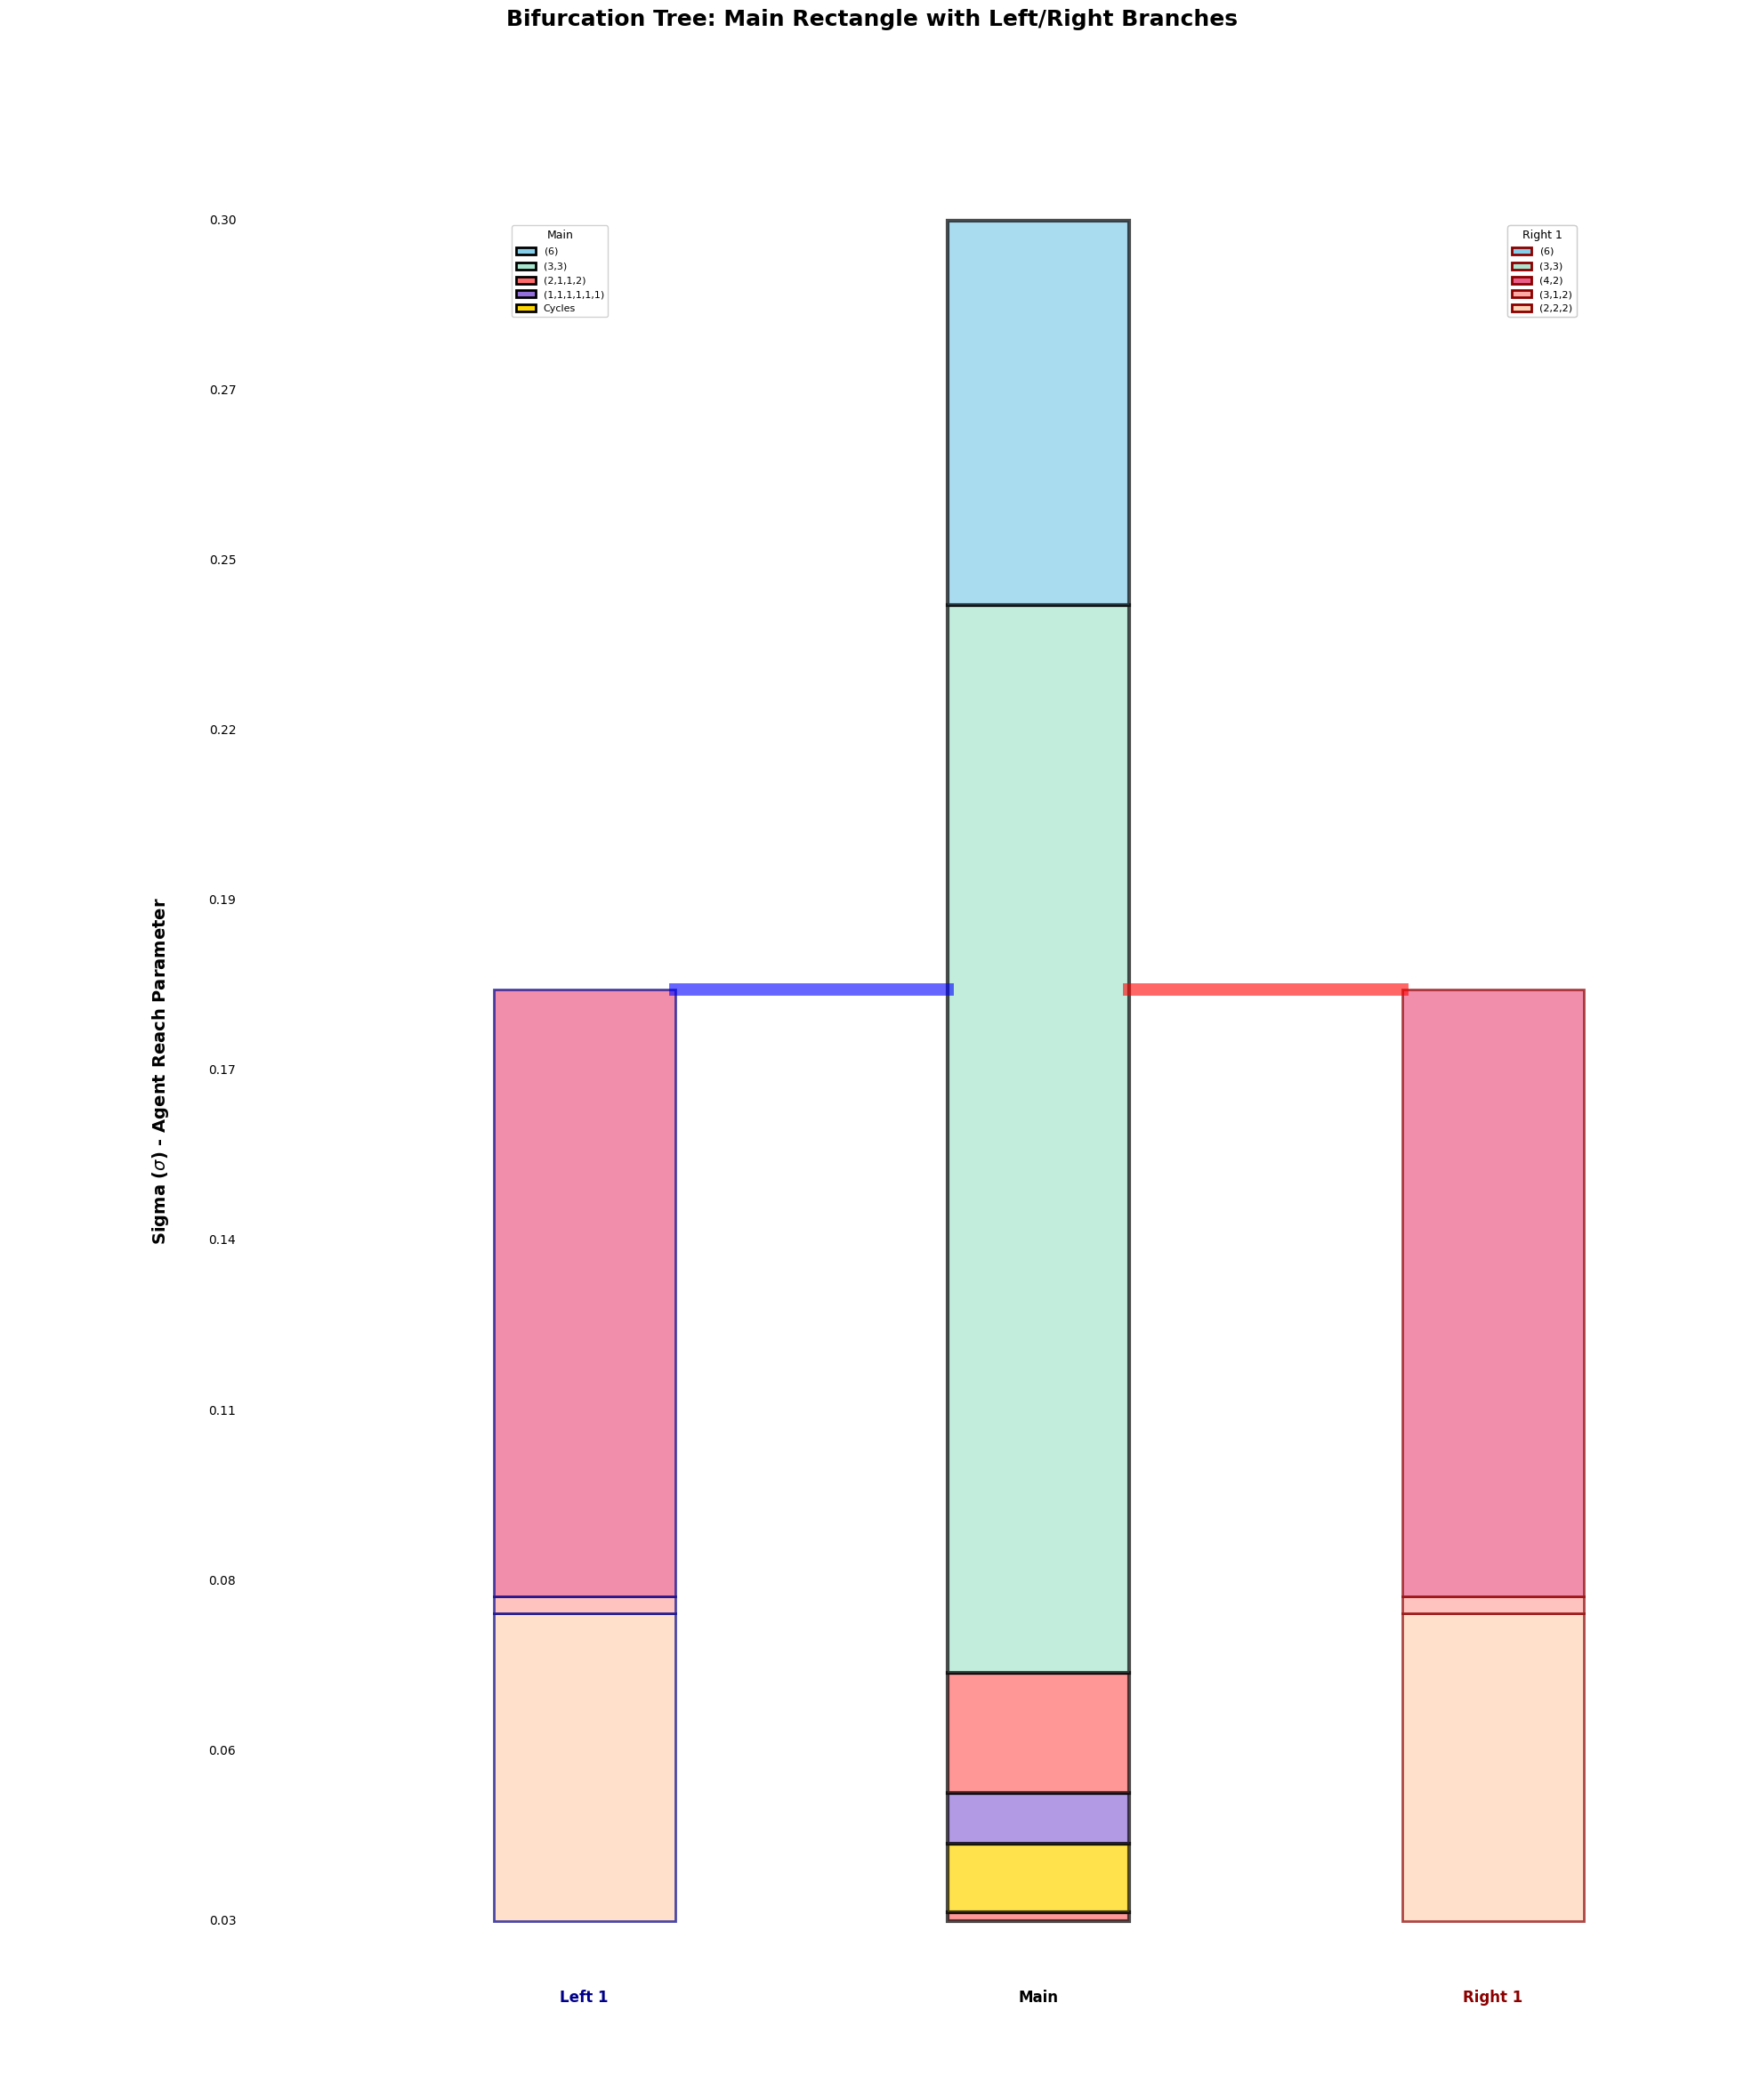

In [87]:
# Example usage with main rectangle and left/right branches
# In this case, matrix1 is main, matrix2 differs so goes to right
fig, ax = bifurcation_tree_plot(
    main_matrix=matrix1,
    left_matrices=[matrix2],  # No left branches in this example
    right_matrices=[matrix2],  # matrix2 differs from matrix1
    reach_parameters=reach_parameters,
    num_agents=num_agents,
    reach_start=reach_start,
    reach_end=reach_end,
    label_to_color=label_to_color,
    figsize=(20, 24),
    rect_width=1.2,
    horizontal_spacing=3.0,
    box_height=10,
    font_size=12,
    show_labels=True
)
plt.show()